# EEG Pain Outcome Prediction Pipeline

Predict **T2-T1 pain change** (Diff) using baseline EEG features.

### Strategy
- Small dataset (n≈74 with EEG+outcome): prioritise regularised, low-complexity models
- **Nested cross-validation** avoids optimistic bias in model selection
- **Permutation test** verifies performance is above chance
- Clinical covariates (baseline pain, group, age …) often dominate EEG in small studies
- Multiple feature sets tested; best combination reported

### Target variants
| Task | Target |
|------|--------|
| Regression | Continuous Diff |
| Binary classification | Diff < median vs ≥ median |
| 3-class classification | Diff<−3 / −3≤Diff≤−2 / Diff>−2 |


In [1]:
# ── 0. Imports ──────────────────────────────────────────────────────────────
import warnings, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from scipy import stats

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_regression, f_classif

from sklearn.linear_model import Ridge, Lasso, ElasticNet, BayesianRidge, LogisticRegression
from sklearn.svm import SVR, SVC
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier,
    ExtraTreesRegressor, ExtraTreesClassifier,
    VotingClassifier,
)

from sklearn.model_selection import (
    StratifiedKFold, KFold, cross_val_score,
    GridSearchCV, permutation_test_score
)
from sklearn.metrics import (
    mean_absolute_error, r2_score,
    balanced_accuracy_score, roc_auc_score,
    ConfusionMatrixDisplay
)

try:
    from xgboost import XGBClassifier, XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('xgboost not installed — XGB models will be skipped')

warnings.filterwarnings('ignore')
np.random.seed(42)

BASE_DIR = Path('.')
DATA_DIR = BASE_DIR / 'processeddata'

print('All imports OK')


All imports OK


## 1. Load Outcomes & Clinical Variables

In [2]:
# ── 1. Load outcomes ─────────────────────────────────────────────────────────
outcomes_path = DATA_DIR / 'Randomization factors and Primary outcome.xlsx'
raw_df = pd.read_excel(outcomes_path)

# Pivot T1/T2 pain scores per patient
pain = raw_df[raw_df['Event Name'].isin(['T1','T2'])].pivot_table(
    index='Patient number', columns='Event Name', values='Pain Unpleasantness'
)
pain['Diff'] = pain['T2'] - pain['T1']

# Grab clinical covariates from T1 rows only
t1_rows = raw_df[raw_df['Event Name'] == 'T1'].copy()
t1_rows = t1_rows.set_index('Patient number')

GROUP_COL  = 'Group assignment - can code the variables (NFB=1; NFB+DL=2; DL=3)'
MONTHS_COL = 'How many months have you been experiencing neuropathy?'

clinical = pd.DataFrame({
    'T1_pain': pain['T1'],
    'Diff':    pain['Diff'],
    'Age':     t1_rows['Age'],
    'Sex':     t1_rows['Sex:'].map({'Female': 0, 'Male': 1}),
    'Group':   t1_rows[GROUP_COL].map({'NFB': 0, 'NFB+DL': 1, 'DL': 2}),
    # Many free-text entries — coerce non-numerics to NaN (imputed later)
    'NeuropMonths': pd.to_numeric(t1_rows[MONTHS_COL], errors='coerce'),
})

# ── Load richer demographics from eeg107_final.csv ───────────────────────────
# Columns: Patient number, Sex, Married, Group assignment, CancerStage_3
# CancerStage_3 values: I_II, III, IV, Unknown (filled for missing records)
cov_path = DATA_DIR / 'eeg107_final.csv'
cov_raw = pd.read_csv(cov_path)
cov_raw['Patient number'] = cov_raw['Patient number'].astype(int)
cov_raw = cov_raw.set_index('Patient number')

# One-hot encode categoricals (stable columns regardless of subset)
sex_cats   = ['Female', 'Male']
group_cats = ['NFB', 'NFB+DL', 'DL']
stage_cats = ['I_II', 'III', 'IV', 'Unknown']

cov_raw['Sex_str']          = pd.Categorical(cov_raw['Sex'], categories=sex_cats)
cov_raw['Group_str']        = pd.Categorical(cov_raw['Group assignment'], categories=group_cats)
cov_raw['CancerStage_str']  = pd.Categorical(cov_raw['CancerStage_3'], categories=stage_cats)

cov_oh = pd.get_dummies(cov_raw[['Married', 'Sex_str', 'Group_str', 'CancerStage_str']],
                        columns=['Sex_str', 'Group_str', 'CancerStage_str'],
                        drop_first=False)
cov_oh['Married'] = cov_raw['Married'].fillna(0).astype(int)

# Map patient id → covariate vector
DEMOG_COLS = list(cov_oh.columns)
pid_to_demog = {pid: row.to_numpy(dtype=float) for pid, row in cov_oh.iterrows()}

print(f'Outcome table shape: {clinical.shape}')
print(f'Diff stats:\n{clinical["Diff"].describe().round(2)}')
print(f'\nGroup distribution:\n{clinical["Group"].value_counts()}')
print(f'\nDemographic feature columns ({len(DEMOG_COLS)}): {DEMOG_COLS}')


Outcome table shape: (336, 6)
Diff stats:
count    181.00
mean      -2.52
std        2.36
min      -10.00
25%       -4.00
50%       -2.00
75%       -1.00
max        4.00
Name: Diff, dtype: float64

Group distribution:
Group
0.0    141
1.0     92
2.0     57
Name: count, dtype: int64

Demographic feature columns (10): ['Married', 'Sex_str_Female', 'Sex_str_Male', 'Group_str_NFB', 'Group_str_NFB+DL', 'Group_str_DL', 'CancerStage_str_I_II', 'CancerStage_str_III', 'CancerStage_str_IV', 'CancerStage_str_Unknown']


In [3]:
# ── 1b. Identify EEG patients and build patient index ────────────────────────
eeg_files = {}
for f in sorted(DATA_DIR.glob('CIPN3*.xlsx')):
    m = re.search(r'CIPN3(\d+)', f.name)
    if m:
        pid = int(m.group(1))
        eeg_files[pid] = f

# Keep only patients with EEG data AND a valid Diff score
common_ids = sorted(
    set(eeg_files.keys()) & set(clinical.index[clinical['Diff'].notna()])
)
print(f"Patients with EEG: {len(eeg_files)}")
print(f"Patients with Diff outcome: {clinical['Diff'].notna().sum()}")
print(f"Overlap (analysis set): {len(common_ids)}")

# Outcome series aligned to common_ids
y_reg   = clinical.loc[common_ids, 'Diff'].values.astype(float)  # continuous
y_bin   = (y_reg < np.median(y_reg)).astype(int)                 # 0=improved more, 1=less
vmin, vmax = -3.0, -2.0
y_tri   = np.where(y_reg < vmin, 0, np.where(y_reg > vmax, 2, 1)).astype(int)  # 3-class

median_diff = np.median(y_reg)
print(f"\nMedian Diff: {median_diff:.1f}")
print(f"Binary (0=Diff<median, 1=Diff>=median): {np.bincount(y_bin)}")
print(f"3-class distribution: {np.bincount(y_tri)}")

Patients with EEG: 107
Patients with Diff outcome: 181
Overlap (analysis set): 107

Median Diff: -2.0
Binary (0=Diff<median, 1=Diff>=median): [54 53]
3-class distribution: [36 38 33]


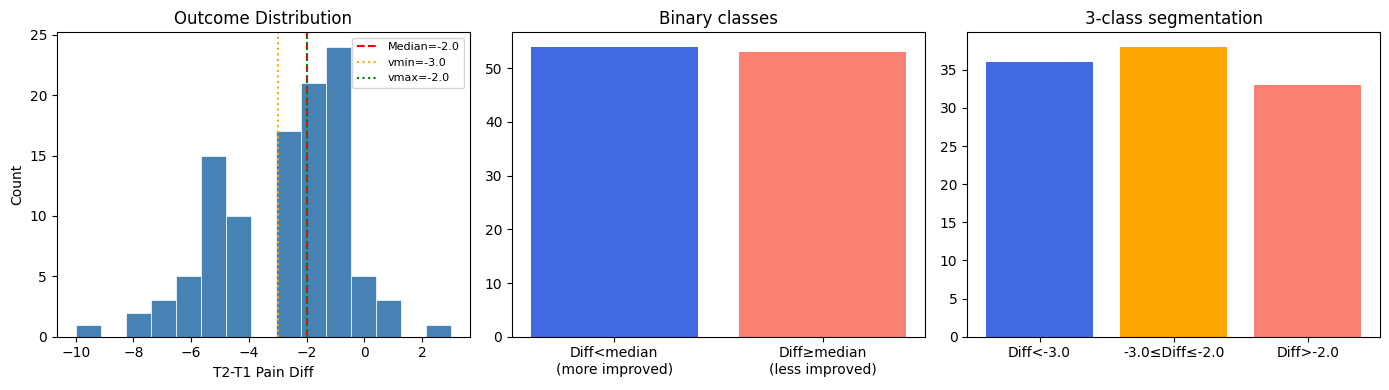


Baseline regression MAE (predict mean): 1.737


In [4]:
# ── 1c. Visualise outcome distribution ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(y_reg, bins=15, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(median_diff, color='red', linestyle='--', label=f'Median={median_diff:.1f}')
axes[0].axvline(vmin, color='orange', linestyle=':', label=f'vmin={vmin}')
axes[0].axvline(vmax, color='green',  linestyle=':', label=f'vmax={vmax}')
axes[0].set_xlabel('T2-T1 Pain Diff'); axes[0].set_ylabel('Count')
axes[0].set_title('Outcome Distribution'); axes[0].legend(fontsize=8)

labels_bin  = ['Diff<median\n(more improved)', 'Diff≥median\n(less improved)']
axes[1].bar(labels_bin, np.bincount(y_bin), color=['royalblue','salmon'])
axes[1].set_title('Binary classes')

labels_tri = [f'Diff<{vmin}', f'{vmin}≤Diff≤{vmax}', f'Diff>{vmax}']
axes[2].bar(labels_tri, np.bincount(y_tri), color=['royalblue','orange','salmon'])
axes[2].set_title('3-class segmentation')

plt.tight_layout(); plt.show()
print(f"\nBaseline regression MAE (predict mean): {mean_absolute_error(y_reg, np.full_like(y_reg, y_reg.mean())):.3f}")

## 2. Feature Engineering

Build multiple feature sets:
- **Clinical**: age, sex, group, baseline pain, neuropathy months  
- **EEG (per sheet)**: mean across channels for each frequency band  
- **EEG + Clinical**: concatenated  
- **PCA-reduced EEG**: top principal components  

In [5]:
# ── 2a. Helper to load one EEG sheet and extract features ───────────────────
def load_sheet_features(patient_ids, sheet_name):
    """
    For each patient, load `sheet_name`, compute per-column mean & std across
    channels (rows).  Returns a DataFrame (patients × 2*bands).
    """
    rows = {}
    for pid in patient_ids:
        try:
            sheet = pd.read_excel(eeg_files[pid], sheet_name=sheet_name, index_col=0)
            if sheet.empty:
                continue
            means = sheet.mean(axis=0).add_prefix('mean_')
            stds  = sheet.std(axis=0).add_prefix('std_')
            rows[pid] = pd.concat([means, stds])
        except Exception:
            pass
    df = pd.DataFrame(rows).T
    df.index.name = 'Patient'
    return df


def load_band_features(patient_ids, sheet_bands):
    """
    Load specific (sheet, band) pairs selected by SHAP analysis.
    For each band column, compute 5 statistics: col_mean, col_std,
    g_mean, g_std, g_median (matching the all5 mode in 5_demog-Best).
    sheet_bands: dict {sheet_name: [band_col, ...]}
    """
    rows = {}
    for pid in patient_ids:
        feats = []
        feat_names = []
        for sheet_name, bands in sheet_bands.items():
            try:
                sheet = pd.read_excel(eeg_files[pid], sheet_name=sheet_name, index_col=0)
            except Exception:
                feats.extend([np.nan] * len(bands) * 5)
                for b in bands:
                    feat_names.extend([f'{sheet_name}/{b}/{s}' for s in ['col_mean','col_std','g_mean','g_std','g_med']])
                continue
            for band in bands:
                sname_short = sheet_name.replace('Z_FFT_', '').replace('_bandpower_uV2', '').replace('_', '')
                if band not in sheet.columns:
                    feats.extend([np.nan] * 5)
                else:
                    col = sheet[band].dropna().values.astype(float)
                    col = col[np.isfinite(col)]
                    if len(col) == 0:
                        feats.extend([np.nan] * 5)
                    else:
                        feats.extend([
                            float(col.mean()),
                            float(col.std()),
                            float(col.mean()),
                            float(col.std()),
                            float(np.median(col)),
                        ])
                feat_names.extend([f'{sname_short}_{band}_{s}' for s in ['col_mean','col_std','g_mean','g_std','g_med']])
        if not rows:  # first patient sets column names
            rows['__cols__'] = feat_names
        rows[pid] = feats
    cols = rows.pop('__cols__', None)
    df = pd.DataFrame(rows, index=cols).T if cols and rows else pd.DataFrame()
    df.index.name = 'Patient'
    return df


# SHAP-selected bands from 5_demog-Best.ipynb
BEST_BANDS = {
    'Z_FFT_Coherence':         ['Beta2', 'Beta3', 'HighBeta'],
    'Z_FFT_abs_bandpower_uV2': ['Alpha2', 'HighBeta', 'Alpha'],
    'Z_FFT_PhaseLag_PLI':      ['Delta', 'HighBeta', 'Alpha1'],
}


# ── 2b. Load all relevant EEG sheets ────────────────────────────────────────
EEG_SHEETS = [
    'FFT_abs_bandpower_uV2',
    'FFT_rel_bandpower_pct',
    'Z_FFT_abs_bandpower_uV2',
    'Z_FFT_rel_bandpower_pct',
    'PeakFreq_Hz',
    'FFT_Coherence',
    'Z_FFT_Coherence',
    'FFT_PhaseLag_PLI',
    'Z_FFT_PhaseLag_PLI',
]

print('Loading EEG feature sheets ...')
eeg_sheet_dfs = {}
for sname in EEG_SHEETS:
    df_s = load_sheet_features(common_ids, sname)
    # keep only rows with >=75% non-NaN features
    thresh = 0.75 * df_s.shape[1]
    df_s = df_s[df_s.notna().sum(axis=1) >= thresh]
    eeg_sheet_dfs[sname] = df_s
    print(f'  {sname:35s}: {df_s.shape[0]} patients, {df_s.shape[1]} features')

print('\nLoading best-bands features ...')
best_bands_df = load_band_features(common_ids, BEST_BANDS)
print(f'  Best-bands: {best_bands_df.shape[0]} patients, {best_bands_df.shape[1]} features')


Loading EEG feature sheets ...
  FFT_abs_bandpower_uV2              : 107 patients, 28 features
  FFT_rel_bandpower_pct              : 107 patients, 28 features
  Z_FFT_abs_bandpower_uV2            : 107 patients, 20 features
  Z_FFT_rel_bandpower_pct            : 107 patients, 20 features
  PeakFreq_Hz                        : 107 patients, 28 features
  FFT_Coherence                      : 107 patients, 20 features
  Z_FFT_Coherence                    : 107 patients, 20 features
  FFT_PhaseLag_PLI                   : 107 patients, 20 features
  Z_FFT_PhaseLag_PLI                 : 107 patients, 20 features

Loading best-bands features ...
  Best-bands: 107 patients, 45 features


In [6]:
# ── 2c. Build consolidated feature sets ─────────────────────────────────────
# Clinical features (always aligned to common_ids)
clin_df = clinical.loc[common_ids, ['T1_pain','Age','Sex','Group','NeuropMonths']].copy()

def align(feature_df, patient_ids):
    """Reindex to patient_ids and fill missing rows with NaN columns."""
    return feature_df.reindex(patient_ids)

# Demographics one-hot (Sex, Married, Group, CancerStage_3)
demog_df = pd.DataFrame(
    {pid: pid_to_demog[pid] for pid in common_ids if pid in pid_to_demog},
    index=DEMOG_COLS
).T
demog_df.index = demog_df.index.astype(int)
demog_df = align(demog_df, common_ids)

# Clinical + demographics
clin_demog_df = pd.concat([clin_df, demog_df], axis=1)

# Power-based EEG (abs + rel + z-scored)
power_df = pd.concat([
    align(eeg_sheet_dfs.get('FFT_abs_bandpower_uV2', pd.DataFrame()), common_ids),
    align(eeg_sheet_dfs.get('FFT_rel_bandpower_pct', pd.DataFrame()), common_ids),
], axis=1)

# Z-scored power
zpower_df = pd.concat([
    align(eeg_sheet_dfs.get('Z_FFT_abs_bandpower_uV2', pd.DataFrame()), common_ids),
    align(eeg_sheet_dfs.get('Z_FFT_rel_bandpower_pct', pd.DataFrame()), common_ids),
], axis=1)

# Connectivity
conn_df = pd.concat([
    align(eeg_sheet_dfs.get('FFT_Coherence',     pd.DataFrame()), common_ids),
    align(eeg_sheet_dfs.get('Z_FFT_Coherence',   pd.DataFrame()), common_ids),
    align(eeg_sheet_dfs.get('FFT_PhaseLag_PLI',  pd.DataFrame()), common_ids),
    align(eeg_sheet_dfs.get('Z_FFT_PhaseLag_PLI',pd.DataFrame()), common_ids),
], axis=1)

# All EEG
all_eeg_df = pd.concat([
    align(df_s, common_ids) for df_s in eeg_sheet_dfs.values()
], axis=1)

# Best bands (SHAP-selected from 5_demog-Best)
best_bands_aligned = align(best_bands_df, common_ids)

# Best bands + demographics
best_bands_demog_df = pd.concat([best_bands_aligned, demog_df], axis=1)

# All EEG + clinical
eeg_clin_df = pd.concat([all_eeg_df, clin_df], axis=1)

# Best bands + full clinical (T1_pain, Age, Sex, Group, NeuropMonths, demographics)
best_bands_clin_df = pd.concat([best_bands_aligned, clin_demog_df], axis=1)

FEATURE_SETS = {
    'Clinical only':           clin_df,
    'Clinical + Demographics': clin_demog_df,
    'Power (raw)':             power_df,
    'Power (z-scored)':        zpower_df,
    'Connectivity':            conn_df,
    'All EEG':                 all_eeg_df,
    'Best Bands':              best_bands_aligned,
    'Best Bands + Demog':      best_bands_demog_df,
    'Best Bands + Clinical':   best_bands_clin_df,
    'EEG + Clinical':          eeg_clin_df,
}

for name, df_ in FEATURE_SETS.items():
    print(f'  {name:30s}: {df_.shape}')


  Clinical only                 : (107, 5)
  Clinical + Demographics       : (107, 15)
  Power (raw)                   : (107, 56)
  Power (z-scored)              : (107, 40)
  Connectivity                  : (107, 80)
  All EEG                       : (107, 204)
  Best Bands                    : (107, 45)
  Best Bands + Demog            : (107, 55)
  Best Bands + Clinical         : (107, 60)
  EEG + Clinical                : (107, 209)


## 3. Model Zoo

In [7]:
# ── 3. Define pipelines + hyperparameter grids ───────────────────────────────
# Preprocessing block: impute NaN → scale → optional PCA
def make_preproc(use_pca=False, n_pca=10):
    steps = [
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
    ]
    if use_pca:
        steps.append(('pca', PCA(n_components=n_pca, random_state=42)))
    return steps


# ── Regression models ────────────────────────────────────────────────────────
REG_MODELS = {
    'Ridge': (
        Pipeline(make_preproc() + [('model', Ridge())]),
        {'model__alpha': [0.01, 0.1, 1, 10, 100, 1000]}
    ),
    'Lasso': (
        Pipeline(make_preproc() + [('model', Lasso(max_iter=5000))]),
        {'model__alpha': [0.001, 0.01, 0.1, 0.5, 1, 5]}
    ),
    'ElasticNet': (
        Pipeline(make_preproc() + [('model', ElasticNet(max_iter=5000))]),
        {'model__alpha': [0.01, 0.1, 1], 'model__l1_ratio': [0.2, 0.5, 0.8]}
    ),
    'BayesianRidge': (
        Pipeline(make_preproc() + [('model', BayesianRidge())]),
        {}
    ),
    'SVR-RBF': (
        Pipeline(make_preproc() + [('model', SVR(kernel='rbf'))]),
        {'model__C': [0.1, 1, 10, 100], 'model__gamma': ['scale','auto']}
    ),
    'SVR-linear': (
        Pipeline(make_preproc() + [('model', SVR(kernel='linear'))]),
        {'model__C': [0.01, 0.1, 1, 10]}
    ),
    'RF-Regressor': (
        Pipeline(make_preproc() + [('model', RandomForestRegressor(random_state=42))]),
        {'model__n_estimators': [100, 300], 'model__max_depth': [2, 3, 5, None]}
    ),
    'ExtraTrees-Reg': (
        Pipeline(make_preproc() + [('model', ExtraTreesRegressor(random_state=42))]),
        {'model__n_estimators': [100, 300], 'model__max_depth': [2, 3, 5, None]}
    ),
    'GBT-Regressor': (
        Pipeline(make_preproc() + [('model', GradientBoostingRegressor(random_state=42))]),
        {'model__n_estimators': [50, 100], 'model__max_depth': [1, 2, 3], 'model__learning_rate': [0.05, 0.1]}
    ),
    'Ridge+PCA': (
        Pipeline(make_preproc(use_pca=True, n_pca=10) + [('model', Ridge())]),
        {'model__alpha': [0.01, 0.1, 1, 10, 100]}
    ),
    'SVR+PCA': (
        Pipeline(make_preproc(use_pca=True, n_pca=10) + [('model', SVR(kernel='rbf'))]),
        {'model__C': [0.1, 1, 10], 'model__gamma': ['scale','auto']}
    ),
}

if HAS_XGB:
    REG_MODELS['XGBoost-Reg'] = (
        Pipeline(make_preproc() + [('model', XGBRegressor(
            objective='reg:squarederror', random_state=42,
            n_jobs=1, verbosity=0, eval_metric='mae'
        ))]),
        {
            'model__n_estimators': [50, 100, 200],
            'model__max_depth': [2, 3, 4],
            'model__learning_rate': [0.05, 0.1, 0.2],
            'model__subsample': [0.7, 1.0],
            'model__colsample_bytree': [0.7, 1.0],
        }
    )


# ── Classification models ────────────────────────────────────────────────────
CLF_MODELS = {
    'LogReg-L2': (
        Pipeline(make_preproc() + [('model', LogisticRegression(max_iter=2000, random_state=42))]),
        {'model__C': [0.001, 0.01, 0.1, 1, 10]}
    ),
    'LogReg-L1': (
        Pipeline(make_preproc() + [('model', LogisticRegression(penalty='l1', solver='saga', max_iter=2000, random_state=42))]),
        {'model__C': [0.001, 0.01, 0.1, 1, 10]}
    ),
    'SVM-RBF': (
        Pipeline(make_preproc() + [('model', SVC(kernel='rbf', probability=True, random_state=42))]),
        {'model__C': [0.1, 1, 10, 100], 'model__gamma': ['scale','auto']}
    ),
    'SVM-linear': (
        Pipeline(make_preproc() + [('model', SVC(kernel='linear', probability=True, random_state=42))]),
        {'model__C': [0.01, 0.1, 1, 10]}
    ),
    'RF-Classifier': (
        Pipeline(make_preproc() + [('model', RandomForestClassifier(random_state=42, class_weight='balanced'))]),
        {'model__n_estimators': [100, 300], 'model__max_depth': [2, 3, 5, None]}
    ),
    'ExtraTrees-Clf': (
        Pipeline(make_preproc() + [('model', ExtraTreesClassifier(random_state=42, class_weight='balanced'))]),
        {'model__n_estimators': [100, 300], 'model__max_depth': [2, 3, 5, None]}
    ),
    'GBT-Classifier': (
        Pipeline(make_preproc() + [('model', GradientBoostingClassifier(random_state=42))]),
        {'model__n_estimators': [50, 100], 'model__max_depth': [1, 2, 3], 'model__learning_rate': [0.05, 0.1]}
    ),
    'LogReg+PCA': (
        Pipeline(make_preproc(use_pca=True, n_pca=10) + [('model', LogisticRegression(max_iter=2000, random_state=42))]),
        {'model__C': [0.001, 0.01, 0.1, 1, 10]}
    ),
    'SVM+PCA': (
        Pipeline(make_preproc(use_pca=True, n_pca=10) + [('model', SVC(kernel='rbf', probability=True, random_state=42))]),
        {'model__C': [0.1, 1, 10], 'model__gamma': ['scale','auto']}
    ),
}

if HAS_XGB:
    CLF_MODELS['XGBoost-Clf'] = (
        Pipeline(make_preproc() + [('model', XGBClassifier(
            objective='binary:logistic', random_state=42,
            n_jobs=1, verbosity=0, eval_metric='logloss',
            use_label_encoder=False
        ))]),
        {
            'model__n_estimators': [50, 100, 200],
            'model__max_depth': [2, 3, 4],
            'model__learning_rate': [0.05, 0.1, 0.2],
            'model__subsample': [0.7, 1.0],
            'model__colsample_bytree': [0.7, 1.0],
        }
    )

print(f'Regression models:     {len(REG_MODELS)}')
print(f'Classification models: {len(CLF_MODELS)}')


Regression models:     12
Classification models: 10


## 4. Nested Cross-Validation Sweep

In [8]:
# ── 4a. Nested CV helper ─────────────────────────────────────────────────────
def nested_cv_regression(X_raw, y, model_dict, outer_cv, inner_cv):
    """
    For each model in model_dict run nested CV:
      outer fold: evaluate on held-out set
      inner fold: GridSearch for hyperparams
    Returns DataFrame with MAE, R² per model.
    """
    results = []
    n_samples = X_raw.shape[0]
    baseline_mae = mean_absolute_error(y, np.full(n_samples, y.mean()))

    for mname, (pipe, param_grid) in model_dict.items():
        fold_maes, fold_r2s = [], []
        for train_idx, test_idx in outer_cv.split(X_raw, y):
            X_tr, X_te = X_raw[train_idx], X_raw[test_idx]
            y_tr, y_te = y[train_idx], y[test_idx]

            if param_grid:
                gs = GridSearchCV(pipe, param_grid, cv=inner_cv,
                                  scoring='neg_mean_absolute_error', n_jobs=-1)
                gs.fit(X_tr, y_tr)
                best = gs.best_estimator_
            else:
                pipe.fit(X_tr, y_tr)
                best = pipe

            y_pred = best.predict(X_te)
            fold_maes.append(mean_absolute_error(y_te, y_pred))
            fold_r2s.append(r2_score(y_te, y_pred))

        results.append({
            'Model': mname,
            'MAE_mean': np.mean(fold_maes),
            'MAE_std':  np.std(fold_maes),
            'R2_mean':  np.mean(fold_r2s),
            'R2_std':   np.std(fold_r2s),
            'vs_baseline': baseline_mae - np.mean(fold_maes),  # positive = better
        })

    return pd.DataFrame(results).sort_values('MAE_mean')


def nested_cv_classification(X_raw, y, model_dict, outer_cv, inner_cv):
    """
    Nested CV for classification: balanced accuracy + ROC-AUC.
    """
    results = []
    n_classes = len(np.unique(y))
    baseline_bacc = 1.0 / n_classes  # majority-class baseline for balanced accuracy

    for mname, (pipe, param_grid) in model_dict.items():
        fold_baccs, fold_aucs = [], []
        for train_idx, test_idx in outer_cv.split(X_raw, y):
            X_tr, X_te = X_raw[train_idx], X_raw[test_idx]
            y_tr, y_te = y[train_idx], y[test_idx]

            if param_grid:
                gs = GridSearchCV(pipe, param_grid, cv=inner_cv,
                                  scoring='balanced_accuracy', n_jobs=-1)
                gs.fit(X_tr, y_tr)
                best = gs.best_estimator_
            else:
                pipe.fit(X_tr, y_tr)
                best = pipe

            y_pred  = best.predict(X_te)
            fold_baccs.append(balanced_accuracy_score(y_te, y_pred))
            try:
                if n_classes == 2:
                    y_prob = best.predict_proba(X_te)[:, 1]
                    fold_aucs.append(roc_auc_score(y_te, y_prob))
                else:
                    y_prob = best.predict_proba(X_te)
                    fold_aucs.append(roc_auc_score(y_te, y_prob, multi_class='ovr'))
            except Exception:
                fold_aucs.append(np.nan)

        results.append({
            'Model': mname,
            'BalAcc_mean': np.mean(fold_baccs),
            'BalAcc_std':  np.std(fold_baccs),
            'AUC_mean':    np.nanmean(fold_aucs),
            'AUC_std':     np.nanstd(fold_aucs),
            'vs_baseline': np.mean(fold_baccs) - baseline_bacc,
        })

    return pd.DataFrame(results).sort_values('BalAcc_mean', ascending=False)


print('Helpers defined.')

Helpers defined.


In [9]:
# ── 4b. Run the full sweep ───────────────────────────────────────────────────
# CV strategy: outer 5-fold, inner 3-fold
outer_cv_reg  = KFold(n_splits=5, shuffle=True, random_state=42)
outer_cv_clf  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv      = KFold(n_splits=3, shuffle=True, random_state=0)

reg_results_all  = {}  # {feature_set_name: DataFrame}
bin_results_all  = {}
tri_results_all  = {}

for fsname, fs_df in FEATURE_SETS.items():
    # Align to common patients that have both EEG and outcome
    available = [p for p in common_ids if p in fs_df.index]
    X_raw = fs_df.loc[available].values.astype(float)
    idx   = [common_ids.index(p) for p in available]  # positions in y arrays

    y_r = y_reg[idx]
    y_b = y_bin[idx]
    y_t = y_tri[idx]

    # Drop all-NaN columns (after imputer will fill, but skip if >80% NaN)
    col_nan_frac = np.isnan(X_raw).mean(axis=0)
    keep_cols    = col_nan_frac < 0.8
    X_raw        = X_raw[:, keep_cols]

    if X_raw.shape[1] == 0:
        print(f"[SKIP] {fsname}: no valid features")
        continue

    # Cap PCA components to min(n_samples-1, n_features, 10)
    # (done inside pipeline, sklearn will handle this automatically)

    print(f"\n{'='*60}")
    print(f"Feature set: {fsname}  [{X_raw.shape[0]} pts × {X_raw.shape[1]} features]")

    # --- Regression ---
    print(f"  Regression ...")
    # Adjust PCA n_components based on available features
    reg_models_adj = {}
    for mname, (pipe, pgrid) in REG_MODELS.items():
        new_pipe = Pipeline([(n, s) for n, s in pipe.steps])
        if 'pca' in dict(pipe.steps):
            max_pca = min(X_raw.shape[0] - 1, X_raw.shape[1], 10)
            new_pipe.set_params(pca__n_components=max_pca)
        reg_models_adj[mname] = (new_pipe, pgrid)
    reg_results_all[fsname] = nested_cv_regression(X_raw, y_r, reg_models_adj, outer_cv_reg, inner_cv)

    # --- Binary classification ---
    print(f"  Binary classification ...")
    clf_models_adj = {}
    for mname, (pipe, pgrid) in CLF_MODELS.items():
        new_pipe = Pipeline([(n, s) for n, s in pipe.steps])
        if 'pca' in dict(pipe.steps):
            max_pca = min(X_raw.shape[0] - 1, X_raw.shape[1], 10)
            new_pipe.set_params(pca__n_components=max_pca)
        clf_models_adj[mname] = (new_pipe, pgrid)
    bin_results_all[fsname] = nested_cv_classification(X_raw, y_b, clf_models_adj, outer_cv_clf, inner_cv)

    # --- 3-class classification ---
    print(f"  3-class classification ...")
    tri_results_all[fsname] = nested_cv_classification(X_raw, y_t, clf_models_adj, StratifiedKFold(n_splits=5, shuffle=True, random_state=42), inner_cv)

print('\nSweep complete.')


Feature set: Clinical only  [107 pts × 5 features]
  Regression ...
  Binary classification ...
  3-class classification ...

Feature set: Clinical + Demographics  [107 pts × 15 features]
  Regression ...
  Binary classification ...
  3-class classification ...

Feature set: Power (raw)  [107 pts × 56 features]
  Regression ...
  Binary classification ...
  3-class classification ...

Feature set: Power (z-scored)  [107 pts × 40 features]
  Regression ...
  Binary classification ...
  3-class classification ...

Feature set: Connectivity  [107 pts × 80 features]
  Regression ...
  Binary classification ...
  3-class classification ...

Feature set: All EEG  [107 pts × 204 features]
  Regression ...
  Binary classification ...
  3-class classification ...

Feature set: Best Bands  [107 pts × 45 features]
  Regression ...
  Binary classification ...
  3-class classification ...

Feature set: Best Bands + Demog  [107 pts × 55 features]
  Regression ...
  Binary classification ...
  3-cla

## 5. Results Summary

In [11]:
# ── 5a. Aggregate all results into single comparison tables ──────────────────
def build_summary(results_dict, metric='MAE_mean', lower_is_better=True):
    rows = []
    for fsname, df_ in results_dict.items():
        best = df_.iloc[0] if lower_is_better else df_.iloc[0]
        rows.append({'Feature Set': fsname, 'Best Model': best['Model'],
                     metric: best[metric], 'vs_baseline': best['vs_baseline']})
    sumdf = pd.DataFrame(rows)
    if lower_is_better:
        sumdf = sumdf.sort_values(metric)
    else:
        sumdf = sumdf.sort_values(metric, ascending=False)
    return sumdf

# Regression (lower MAE = better)
baseline_mae = mean_absolute_error(y_reg, np.full_like(y_reg, y_reg.mean()))
print(f"Baseline MAE (predict mean): {baseline_mae:.3f}")
print()
print("═" * 60)
print("REGRESSION — Best model per feature set")
print("═" * 60)
reg_summary = build_summary(reg_results_all, 'MAE_mean', lower_is_better=True)
print(reg_summary.to_string(index=False))

print()
print("═" * 60)
print("BINARY CLASSIFICATION — Best model per feature set")
print("═" * 60)
bin_summary = build_summary(bin_results_all, 'BalAcc_mean', lower_is_better=False)
print(bin_summary.to_string(index=False))

print()
print("═" * 60)
print("3-CLASS CLASSIFICATION — Best model per feature set")
print("═" * 60)
tri_summary = build_summary(tri_results_all, 'BalAcc_mean', lower_is_better=False)
print(tri_summary.to_string(index=False))

Baseline MAE (predict mean): 1.737

════════════════════════════════════════════════════════════
REGRESSION — Best model per feature set
════════════════════════════════════════════════════════════
            Feature Set     Best Model  MAE_mean  vs_baseline
  Best Bands + Clinical ExtraTrees-Reg  1.424634     0.312112
Clinical + Demographics   RF-Regressor  1.445926     0.290820
          Clinical only   RF-Regressor  1.468525     0.268221
         EEG + Clinical          Lasso  1.515869     0.220876
     Best Bands + Demog        SVR-RBF  1.614864     0.121881
             Best Bands        SVR-RBF  1.617220     0.119525
            Power (raw)    XGBoost-Reg  1.720148     0.016598
       Power (z-scored)      Ridge+PCA  1.755941    -0.019195
           Connectivity          Lasso  1.774728    -0.037982
                All EEG          Lasso  1.774728    -0.037982

════════════════════════════════════════════════════════════
BINARY CLASSIFICATION — Best model per feature set
═══════

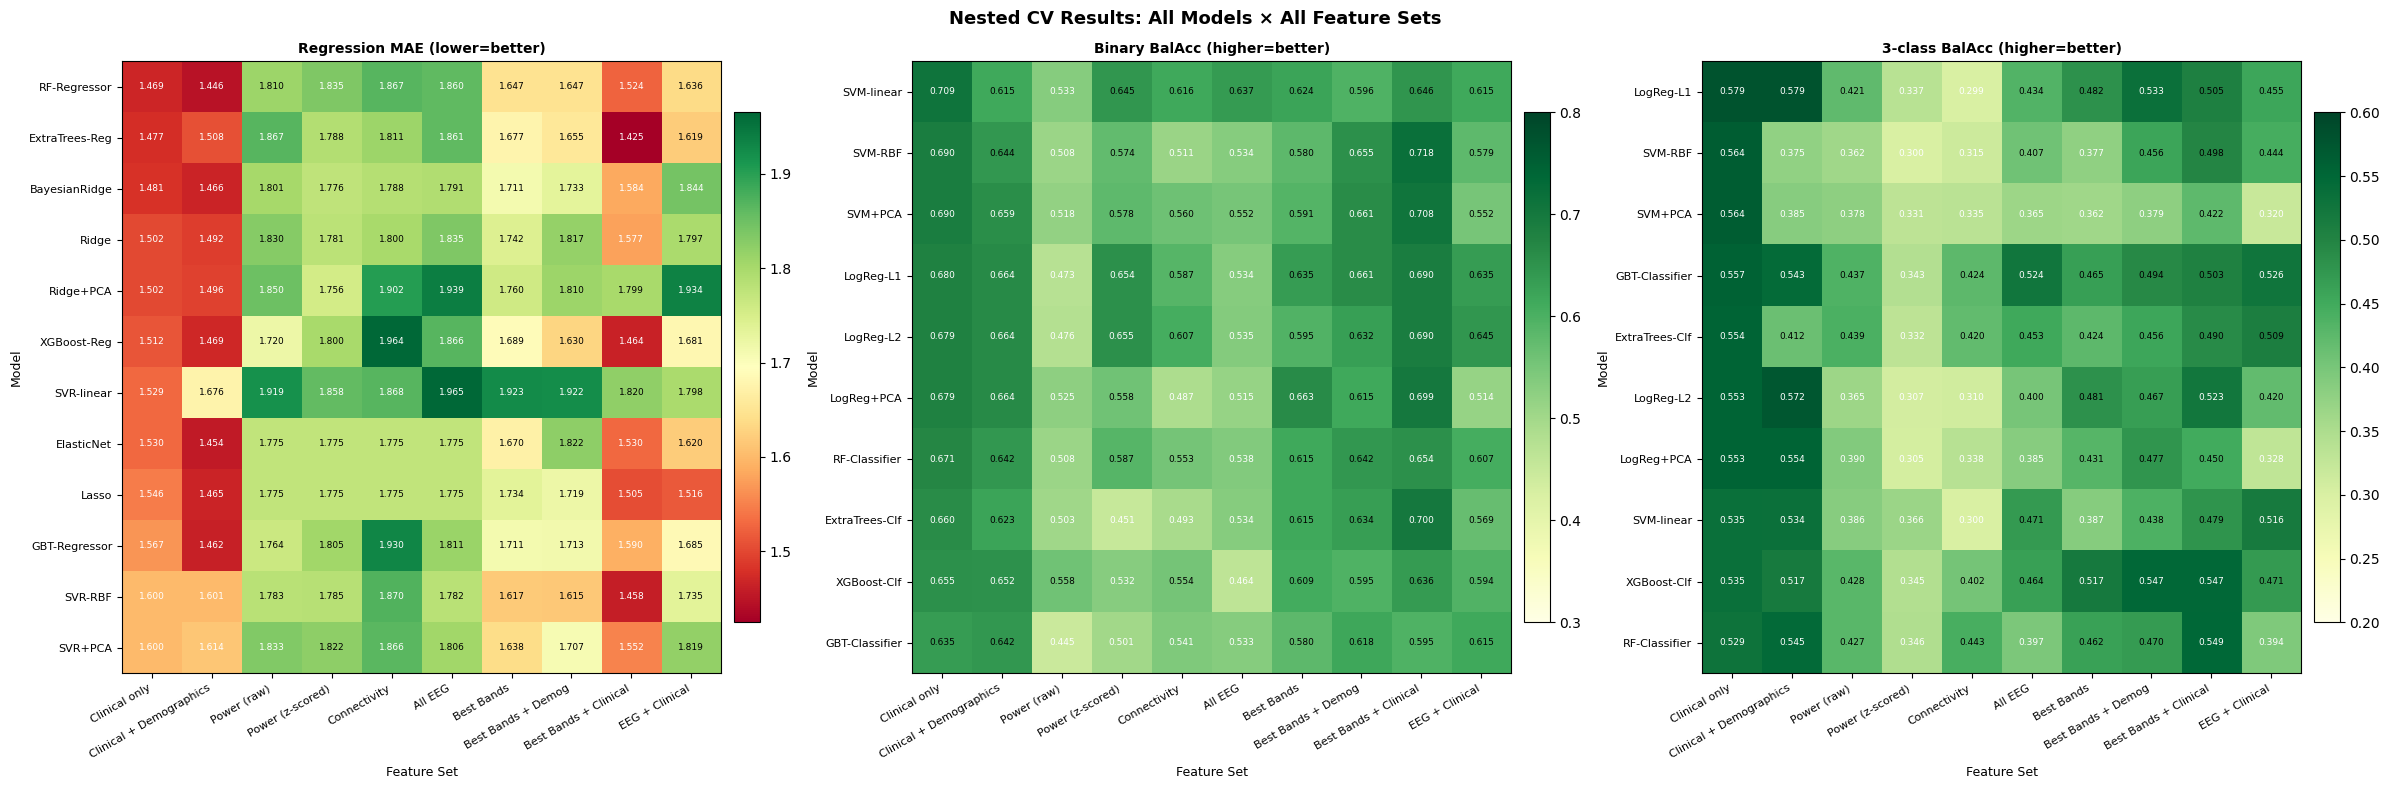

In [12]:
# ── 5b. Heatmap: all models × all feature sets (pure matplotlib) ─────────────
def make_heatmap(results_dict, metric, title, ax, vmin=None, vmax=None, cmap='YlGn'):
    # Build pivot: rows=models, cols=feature sets
    first_df = list(results_dict.values())[0]
    all_models = list(first_df['Model'])
    pivot = pd.DataFrame(index=all_models)
    for fsname, df_ in results_dict.items():
        col = df_.set_index('Model')[metric]
        pivot[fsname] = col
    pivot = pivot.fillna(np.nan).astype(float)

    data   = pivot.values
    feat_labels = list(pivot.columns)
    model_labels = list(pivot.index)

    im = ax.imshow(data, aspect='auto', cmap=cmap,
                   vmin=vmin if vmin is not None else np.nanmin(data),
                   vmax=vmax if vmax is not None else np.nanmax(data))
    ax.set_xticks(range(len(feat_labels)));  ax.set_xticklabels(feat_labels, rotation=30, ha='right', fontsize=8)
    ax.set_yticks(range(len(model_labels))); ax.set_yticklabels(model_labels, fontsize=8)

    # Annotate cells
    norm_vals = (data - np.nanmin(data)) / (np.nanmax(data) - np.nanmin(data) + 1e-9)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]
            if not np.isnan(val):
                text_color = 'white' if norm_vals[i, j] < 0.35 or norm_vals[i, j] > 0.75 else 'black'
                ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                        fontsize=6.5, color=text_color)

    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Feature Set', fontsize=9)
    ax.set_ylabel('Model', fontsize=9)
    return pivot

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

make_heatmap(reg_results_all,  'MAE_mean',    'Regression MAE (lower=better)',
             axes[0], cmap='RdYlGn')
make_heatmap(bin_results_all,  'BalAcc_mean', 'Binary BalAcc (higher=better)',
             axes[1], vmin=0.3, vmax=0.8, cmap='YlGn')
make_heatmap(tri_results_all,  'BalAcc_mean', '3-class BalAcc (higher=better)',
             axes[2], vmin=0.2, vmax=0.6, cmap='YlGn')

plt.suptitle('Nested CV Results: All Models × All Feature Sets', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Best Model Deep Dive

In [13]:
# ── 6a. Find overall best across all feature sets ────────────────────────────
best_reg_row  = reg_summary.iloc[0]   # lowest MAE
best_bin_row  = bin_summary.iloc[0]   # highest balanced accuracy
best_tri_row  = tri_summary.iloc[0]

print("Best regression  :", best_reg_row[['Feature Set','Best Model','MAE_mean']].to_dict())
print("Best binary clf  :", best_bin_row[['Feature Set','Best Model','BalAcc_mean']].to_dict())
print("Best 3-class clf :", best_tri_row[['Feature Set','Best Model','BalAcc_mean']].to_dict())

Best regression  : {'Feature Set': 'Best Bands + Clinical', 'Best Model': 'ExtraTrees-Reg', 'MAE_mean': 1.4246339871478444}
Best binary clf  : {'Feature Set': 'Best Bands + Clinical', 'Best Model': 'SVM-RBF', 'BalAcc_mean': 0.7181818181818181}
Best 3-class clf : {'Feature Set': 'Clinical only', 'Best Model': 'LogReg-L1', 'BalAcc_mean': 0.5793650793650793}


[Binary] SVM-RBF on 'Best Bands + Clinical'
  True balanced accuracy: 0.719
  Permutation mean:       0.498 ± 0.062
  p-value:                0.0050


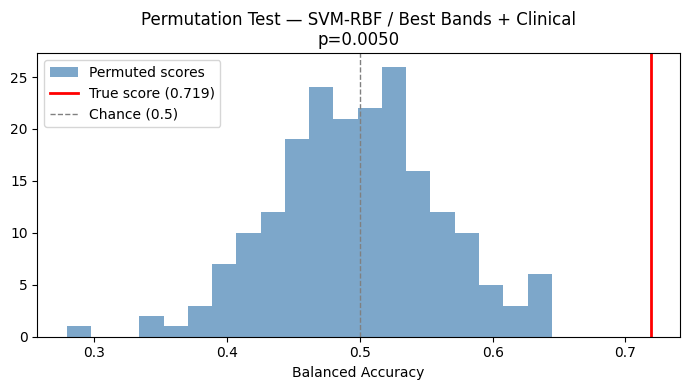

In [14]:
# ── 6b. Permutation test for best binary classifier ──────────────────────────
best_bin_fs   = best_bin_row['Feature Set']
best_bin_mdl  = best_bin_row['Best Model']

available_b = [p for p in common_ids if p in FEATURE_SETS[best_bin_fs].index]
idx_b       = [common_ids.index(p) for p in available_b]
X_best_b    = FEATURE_SETS[best_bin_fs].loc[available_b].values.astype(float)
y_best_b    = y_bin[idx_b]

# Fix NaN columns
keep = np.isnan(X_best_b).mean(axis=0) < 0.8
X_best_b = X_best_b[:, keep]

# Use the pipeline from CLF_MODELS (no grid search for permutation test)
perm_pipe_b, _ = CLF_MODELS[best_bin_mdl]

score_b, perm_scores_b, p_val_b = permutation_test_score(
    perm_pipe_b, X_best_b, y_best_b,
    scoring='balanced_accuracy',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_permutations=200, random_state=42, n_jobs=-1
)

print(f"[Binary] {best_bin_mdl} on '{best_bin_fs}'")
print(f"  True balanced accuracy: {score_b:.3f}")
print(f"  Permutation mean:       {perm_scores_b.mean():.3f} ± {perm_scores_b.std():.3f}")
print(f"  p-value:                {p_val_b:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(perm_scores_b, bins=20, alpha=0.7, color='steelblue', label='Permuted scores')
ax.axvline(score_b, color='red', lw=2, label=f'True score ({score_b:.3f})')
ax.axvline(0.5, color='gray', lw=1, linestyle='--', label='Chance (0.5)')
ax.set_xlabel('Balanced Accuracy')
ax.set_title(f'Permutation Test — {best_bin_mdl} / {best_bin_fs}\np={p_val_b:.4f}')
ax.legend()
plt.tight_layout(); plt.show()

[Regression] ExtraTrees-Reg on 'Best Bands + Clinical'
  True neg-MAE:      -1.442 → MAE=1.442
  Permutation mean:  -1.895 ± 0.093
  p-value:           0.0050


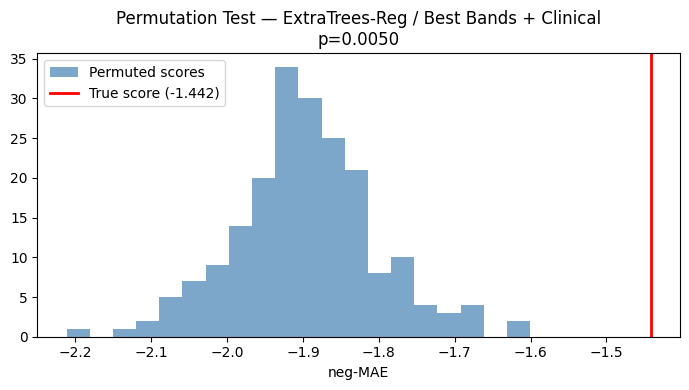

In [15]:
# ── 6c. Permutation test for best regression model ───────────────────────────
best_reg_fs  = best_reg_row['Feature Set']
best_reg_mdl = best_reg_row['Best Model']

available_r = [p for p in common_ids if p in FEATURE_SETS[best_reg_fs].index]
idx_r       = [common_ids.index(p) for p in available_r]
X_best_r    = FEATURE_SETS[best_reg_fs].loc[available_r].values.astype(float)
y_best_r    = y_reg[idx_r]

keep = np.isnan(X_best_r).mean(axis=0) < 0.8
X_best_r = X_best_r[:, keep]

perm_pipe_r, _ = REG_MODELS[best_reg_mdl]

score_r, perm_scores_r, p_val_r = permutation_test_score(
    perm_pipe_r, X_best_r, y_best_r,
    scoring='neg_mean_absolute_error',
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    n_permutations=200, random_state=42, n_jobs=-1
)

print(f"[Regression] {best_reg_mdl} on '{best_reg_fs}'")
print(f"  True neg-MAE:      {score_r:.3f} → MAE={-score_r:.3f}")
print(f"  Permutation mean:  {perm_scores_r.mean():.3f} ± {perm_scores_r.std():.3f}")
print(f"  p-value:           {p_val_r:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(perm_scores_r, bins=20, alpha=0.7, color='steelblue', label='Permuted scores')
ax.axvline(score_r, color='red', lw=2, label=f'True score ({score_r:.3f})')
ax.set_xlabel('neg-MAE')
ax.set_title(f'Permutation Test — {best_reg_mdl} / {best_reg_fs}\np={p_val_r:.4f}')
ax.legend()
plt.tight_layout(); plt.show()

## 7. Feature Importance & Interpretability

In [16]:
# ── 7a. Fit best binary classifier on full data and inspect coefficients/importances
best_bin_fs   = best_bin_row['Feature Set']
best_bin_mdl  = best_bin_row['Best Model']

available_b = [p for p in common_ids if p in FEATURE_SETS[best_bin_fs].index]
idx_b       = [common_ids.index(p) for p in available_b]
X_full_b    = FEATURE_SETS[best_bin_fs].loc[available_b].values.astype(float)
y_full_b    = y_bin[idx_b]
feat_names  = list(FEATURE_SETS[best_bin_fs].columns)

keep_b      = np.isnan(X_full_b).mean(axis=0) < 0.8
X_full_b    = X_full_b[:, keep_b]
feat_names_b = [feat_names[i] for i, k in enumerate(keep_b) if k]

pipe_b, pgrid_b = CLF_MODELS[best_bin_mdl]
if pgrid_b:
    inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)
    gs_b  = GridSearchCV(pipe_b, pgrid_b, cv=inner, scoring='balanced_accuracy', n_jobs=-1)
    gs_b.fit(X_full_b, y_full_b)
    best_pipe_b = gs_b.best_estimator_
    print(f"Best params: {gs_b.best_params_}")
else:
    pipe_b.fit(X_full_b, y_full_b)
    best_pipe_b = pipe_b

print(f"Fitted {best_bin_mdl} on full dataset")

Best params: {'model__C': 10, 'model__gamma': 'scale'}
Fitted SVM-RBF on full dataset


In [17]:
# ── 7b. Extract and plot feature importances ─────────────────────────────────
def get_importances(pipe, feat_names):
    mdl = pipe.named_steps['model']
    # Handle PCA: we can only show PC coefficients mapped back to original features
    pca = pipe.named_steps.get('pca', None)

    if hasattr(mdl, 'coef_'):
        coef = mdl.coef_.ravel()
        if pca is not None:
            # Map PC weights back through PCA components
            coef_orig = coef @ pca.components_  # (n_orig_features,)
            return feat_names, coef_orig
        return feat_names, coef
    elif hasattr(mdl, 'feature_importances_'):
        return feat_names, mdl.feature_importances_
    else:
        return None, None

names_b, imp_b = get_importances(best_pipe_b, feat_names_b)

if imp_b is not None:
    top_k = 20
    sorted_idx = np.argsort(np.abs(imp_b))[::-1][:top_k]
    top_names  = [names_b[i] for i in sorted_idx]
    top_vals   = imp_b[sorted_idx]

    fig, ax = plt.subplots(figsize=(8, 6))
    colors = ['royalblue' if v >= 0 else 'salmon' for v in top_vals]
    ax.barh(range(top_k), top_vals[::-1], color=colors[::-1])
    ax.set_yticks(range(top_k))
    ax.set_yticklabels(top_names[::-1], fontsize=8)
    ax.axvline(0, color='black', lw=0.5)
    ax.set_title(f'Top {top_k} Features — {best_bin_mdl} on {best_bin_fs}')
    ax.set_xlabel('Importance / Coefficient')
    plt.tight_layout(); plt.show()
else:
    print(f"Model {best_bin_mdl} does not expose feature importances / coefficients.")

Model SVM-RBF does not expose feature importances / coefficients.


LOO balanced accuracy: 0.691


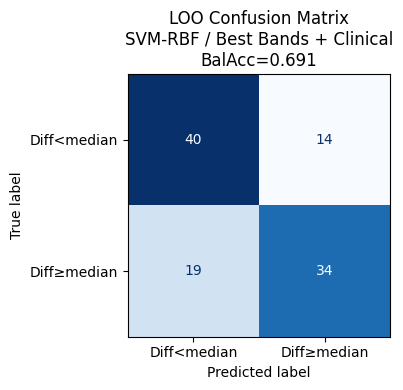

In [18]:
# ── 7c. Confusion matrix for best binary classifier (leave-one-out) ──────────
from sklearn.model_selection import LeaveOneOut, cross_val_predict

# Use the best pipeline but without inner GridSearch for speed
loo = LeaveOneOut()
y_pred_loo = cross_val_predict(
    best_pipe_b, X_full_b, y_full_b,
    cv=loo, method='predict'
)

bacc_loo = balanced_accuracy_score(y_full_b, y_pred_loo)
print(f"LOO balanced accuracy: {bacc_loo:.3f}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_full_b, y_pred_loo,
    display_labels=['Diff<median', 'Diff≥median'],
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title(f'LOO Confusion Matrix\n{best_bin_mdl} / {best_bin_fs}\nBalAcc={bacc_loo:.3f}')
plt.tight_layout(); plt.show()

## 8. Univariate Feature Screening

Screening 28 unique features across 107 patients


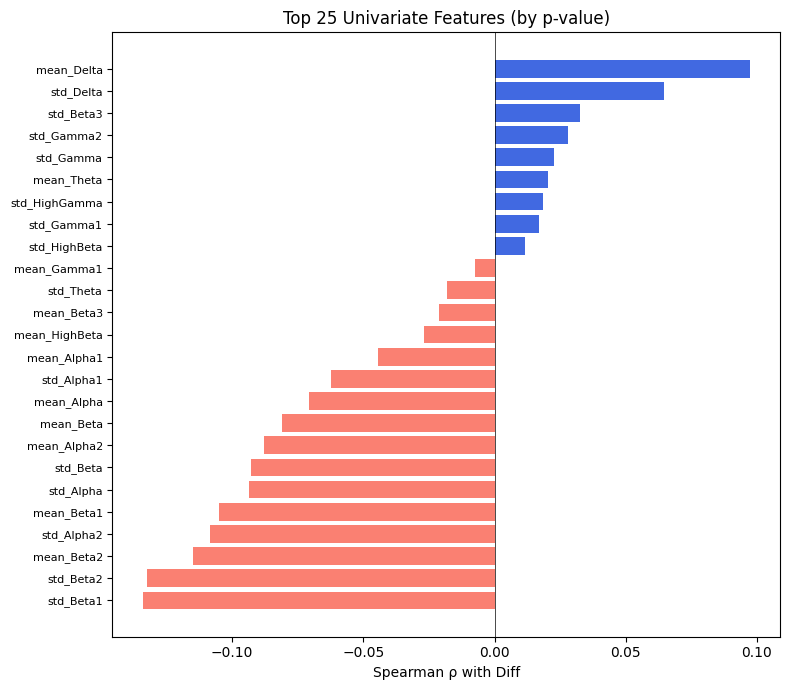


Top 10 features by p-value:
    feature       rho     pval
  std_Beta1 -0.134044 0.168667
  std_Beta2 -0.132386 0.174045
 mean_Beta2 -0.114900 0.238602
 std_Alpha2 -0.108342 0.266650
 mean_Beta1 -0.105105 0.281287
 mean_Delta  0.097251 0.318997
  std_Alpha -0.093418 0.338532
   std_Beta -0.092683 0.342361
mean_Alpha2 -0.088017 0.367318
  mean_Beta -0.080843 0.407797


In [19]:
# ── 8. Univariate correlations: which features correlate most with Diff? ─────
diff_aligned = pd.Series(y_reg, index=common_ids)

all_eeg_aligned = all_eeg_df.reindex(common_ids).copy()
n_dup = all_eeg_aligned.columns.duplicated().sum()
if n_dup > 0:
    print(f"Warning: {n_dup} duplicate columns detected — dropping duplicates. Re-run cell 8 to fix at source.")
    all_eeg_aligned = all_eeg_aligned.loc[:, ~all_eeg_aligned.columns.duplicated()]
print(f"Screening {all_eeg_aligned.shape[1]} unique features across {all_eeg_aligned.shape[0]} patients")

corr_rows = []
for col in all_eeg_aligned.columns:
    x = all_eeg_aligned[col]
    if isinstance(x, pd.DataFrame):
        continue
    x = x.dropna()
    y_shared = diff_aligned[x.index].dropna()
    x = x.loc[y_shared.index]
    if len(x) < 10:
        continue
    result = stats.spearmanr(x, y_shared)
    r, p = float(result.statistic), float(result.pvalue)
    corr_rows.append({'feature': col, 'rho': r, 'pval': p})

corr_df = pd.DataFrame(corr_rows).sort_values('pval').reset_index(drop=True)

top_n = min(25, len(corr_df))
fig, ax = plt.subplots(figsize=(8, 7))
top_corrs = corr_df.head(top_n).sort_values('rho')
colors = ['royalblue' if r >= 0 else 'salmon' for r in top_corrs['rho']]
ax.barh(range(top_n), top_corrs['rho'], color=colors)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_corrs['feature'], fontsize=8)
ax.axvline(0, color='black', lw=0.5)
ax.set_xlabel('Spearman ρ with Diff')
ax.set_title(f'Top {top_n} Univariate Features (by p-value)')
plt.tight_layout(); plt.show()

print(f"\nTop 10 features by p-value:")
print(corr_df.head(10).to_string(index=False))


Top-k feature selection (SVM-RBF, binary):
 top_k  BalAcc_mean  BalAcc_std
     5     0.552727    0.049843
    10     0.591818    0.090197
    20     0.571818    0.083339
    50     0.581818    0.079721


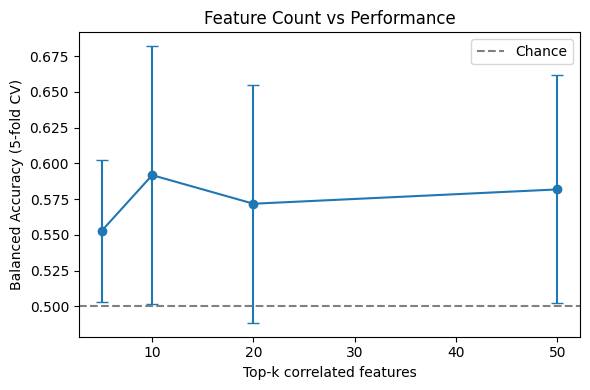

In [20]:
# ── 8b. Top-k univariate feature selection pipeline ──────────────────────────
# Build a feature set using only top-k correlated EEG features + clinical
TOP_K_LIST = [5, 10, 20, 50]

topk_results = []
for k in TOP_K_LIST:
    top_feats = corr_df.head(k)['feature'].tolist()
    X_topk = all_eeg_df.reindex(common_ids)[top_feats].values.astype(float)
    y_topk = y_bin

    keep = np.isnan(X_topk).mean(axis=0) < 0.8
    X_topk = X_topk[:, keep]

    # Drop rows with too many NaNs
    row_ok = np.isnan(X_topk).mean(axis=1) < 0.5
    X_topk_c = X_topk[row_ok]
    y_topk_c = y_topk[row_ok]

    pipe_svm, _ = CLF_MODELS['SVM-RBF']
    cv_scores   = cross_val_score(
        pipe_svm, X_topk_c, y_topk_c,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='balanced_accuracy'
    )
    topk_results.append({'top_k': k, 'BalAcc_mean': cv_scores.mean(), 'BalAcc_std': cv_scores.std()})

topk_df = pd.DataFrame(topk_results)
print("Top-k feature selection (SVM-RBF, binary):")
print(topk_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(topk_df['top_k'], topk_df['BalAcc_mean'], yerr=topk_df['BalAcc_std'],
            marker='o', capsize=4)
ax.axhline(0.5, color='gray', linestyle='--', label='Chance')
ax.set_xlabel('Top-k correlated features')
ax.set_ylabel('Balanced Accuracy (5-fold CV)')
ax.set_title('Feature Count vs Performance')
ax.legend(); plt.tight_layout(); plt.show()

## 9. Regression Scatter & Residuals

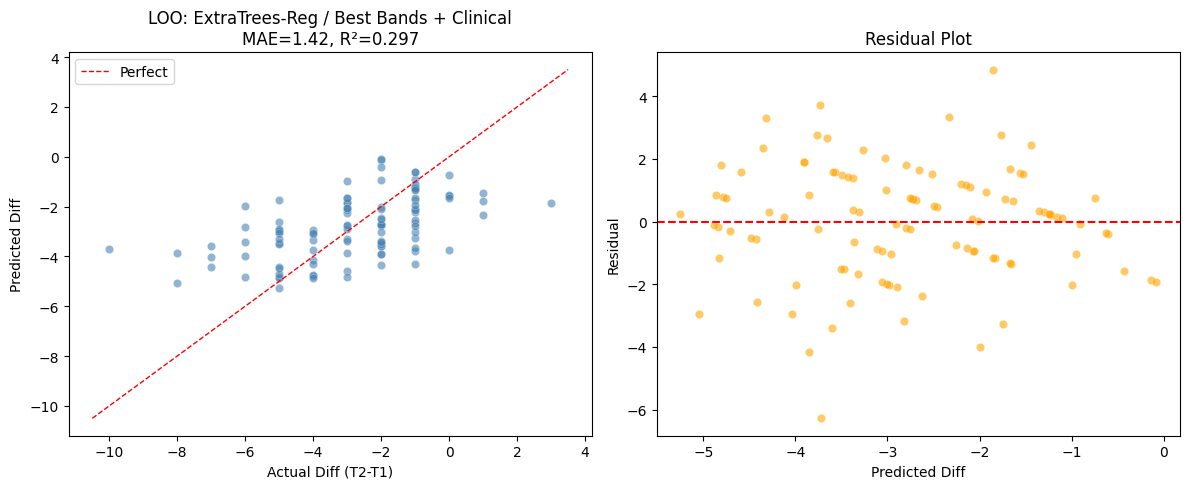

LOO MAE: 1.420  (baseline = 1.737)
LOO R²:  0.297


In [21]:
# ── 9. Predicted vs actual for best regression model (LOO) ───────────────────
best_reg_fs  = best_reg_row['Feature Set']
best_reg_mdl = best_reg_row['Best Model']

available_r = [p for p in common_ids if p in FEATURE_SETS[best_reg_fs].index]
idx_r       = [common_ids.index(p) for p in available_r]
X_full_r    = FEATURE_SETS[best_reg_fs].loc[available_r].values.astype(float)
y_full_r    = y_reg[idx_r]

keep = np.isnan(X_full_r).mean(axis=0) < 0.8
X_full_r = X_full_r[:, keep]

pipe_r, _ = REG_MODELS[best_reg_mdl]

y_pred_r_loo = cross_val_predict(
    pipe_r, X_full_r, y_full_r,
    cv=LeaveOneOut()
)

loo_mae = mean_absolute_error(y_full_r, y_pred_r_loo)
loo_r2  = r2_score(y_full_r, y_pred_r_loo)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter: predicted vs actual
axes[0].scatter(y_full_r, y_pred_r_loo, alpha=0.6, color='steelblue', edgecolors='white', lw=0.3)
lims = [min(y_full_r.min(), y_pred_r_loo.min()) - 0.5,
        max(y_full_r.max(), y_pred_r_loo.max()) + 0.5]
axes[0].plot(lims, lims, 'r--', lw=1, label='Perfect')
axes[0].set_xlabel('Actual Diff (T2-T1)')
axes[0].set_ylabel('Predicted Diff')
axes[0].set_title(f'LOO: {best_reg_mdl} / {best_reg_fs}\nMAE={loo_mae:.2f}, R²={loo_r2:.3f}')
axes[0].legend()

# Residuals
residuals = y_full_r - y_pred_r_loo
axes[1].scatter(y_pred_r_loo, residuals, alpha=0.6, color='orange', edgecolors='white', lw=0.3)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted Diff')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')

plt.tight_layout(); plt.show()
print(f"LOO MAE: {loo_mae:.3f}  (baseline = {baseline_mae:.3f})")
print(f"LOO R²:  {loo_r2:.3f}")

## 10. Optional: XGBoost (if installed)

In [22]:
# ── 10. Try XGBoost if available ─────────────────────────────────────────────
try:
    import xgboost as xgb
    print(f"XGBoost version: {xgb.__version__}")
    HAS_XGB = True
except ImportError:
    print('XGBoost not installed. Skipping.')
    HAS_XGB = False

if HAS_XGB:
    XGB_REG = Pipeline(make_preproc() + [
        ('model', xgb.XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05,
                                    subsample=0.8, colsample_bytree=0.8,
                                    random_state=42, verbosity=0, n_jobs=-1))
    ])
    XGB_CLF = Pipeline(make_preproc() + [
        ('model', xgb.XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05,
                                     subsample=0.8, colsample_bytree=0.8,
                                     eval_metric='logloss', random_state=42, verbosity=0, n_jobs=-1))
    ])

    xgb_reg_results = {}
    xgb_bin_results = {}

    for fsname, fs_df in FEATURE_SETS.items():
        available = [p for p in common_ids if p in fs_df.index]
        idx = [common_ids.index(p) for p in available]
        X_raw = fs_df.loc[available].values.astype(float)
        y_r = y_reg[idx]; y_b = y_bin[idx]
        keep = np.isnan(X_raw).mean(axis=0) < 0.8
        X_raw = X_raw[:, keep]

        scores_r = cross_val_score(XGB_REG, X_raw, y_r,
                                   cv=KFold(n_splits=5, shuffle=True, random_state=42),
                                   scoring='neg_mean_absolute_error')
        scores_b = cross_val_score(XGB_CLF, X_raw, y_b,
                                   cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                                   scoring='balanced_accuracy')
        xgb_reg_results[fsname] = (-scores_r.mean(), scores_r.std())
        xgb_bin_results[fsname] = (scores_b.mean(), scores_b.std())

    print("\nXGBoost — Regression (MAE) vs Binary (BalAcc):")
    for fs in FEATURE_SETS:
        r_mae, r_std = xgb_reg_results.get(fs, (np.nan, np.nan))
        b_acc, b_std = xgb_bin_results.get(fs, (np.nan, np.nan))
        print(f"  {fs:25s}  MAE={r_mae:.3f}±{r_std:.3f}  BalAcc={b_acc:.3f}±{b_std:.3f}")

XGBoost version: 3.2.0

XGBoost — Regression (MAE) vs Binary (BalAcc):
  Clinical only              MAE=1.555±0.255  BalAcc=0.655±0.077
  Clinical + Demographics    MAE=1.404±0.225  BalAcc=0.635±0.091
  Power (raw)                MAE=1.697±0.188  BalAcc=0.510±0.117
  Power (z-scored)           MAE=1.858±0.185  BalAcc=0.549±0.066
  Connectivity               MAE=1.940±0.410  BalAcc=0.554±0.060
  All EEG                    MAE=1.836±0.249  BalAcc=0.618±0.095
  Best Bands                 MAE=1.691±0.126  BalAcc=0.635±0.071
  Best Bands + Demog         MAE=1.624±0.094  BalAcc=0.655±0.062
  Best Bands + Clinical      MAE=1.522±0.212  BalAcc=0.653±0.088
  EEG + Clinical             MAE=1.699±0.337  BalAcc=0.609±0.046


## 11. Summary Dashboard

In [23]:
# ── 11. Final summary ────────────────────────────────────────────────────────
print("="*70)
print("FINAL SUMMARY")
print("="*70)
print(f"\nDataset: {len(common_ids)} patients | Target: T2-T1 Pain Diff")
print(f"Diff mean: {y_reg.mean():.2f}, std: {y_reg.std():.2f}")
print()
print("BASELINES")
print(f"  Regression   — predict-mean MAE: {baseline_mae:.3f}")
print(f"  Binary clf   — balanced accuracy at chance: 0.500")
print(f"  3-class clf  — balanced accuracy at chance: 0.333")
print()
print("BEST MODELS (nested 5-fold CV)")
best_reg_mdl = best_reg_row['Best Model']
best_bin_mdl = best_bin_row['Best Model']
best_tri_mdl = best_tri_row['Best Model']
print(f"  Regression  : {best_reg_mdl} on '{best_reg_row['Feature Set']}'")
print(f"    MAE = {best_reg_row['MAE_mean']:.3f}  (Δ vs baseline = {best_reg_row['vs_baseline']:+.3f})")
print()
print(f"  Binary clf  : {best_bin_mdl} on '{best_bin_row['Feature Set']}'")
print(f"    BalAcc = {best_bin_row['BalAcc_mean']:.3f}  (Δ vs chance = {best_bin_row['vs_baseline']:+.3f})")
print()
print(f"  3-class clf : {best_tri_mdl} on '{best_tri_row['Feature Set']}'")
print(f"    BalAcc = {best_tri_row['BalAcc_mean']:.3f}  (Δ vs chance = {best_tri_row['vs_baseline']:+.3f})")
print()
print("PERMUTATION TESTS")
print(f"  Binary clf  p-value: {p_val_b:.4f}" + (" ✓ SIGNIFICANT" if p_val_b < 0.05 else " ✗ not significant"))
print(f"  Regression  p-value: {p_val_r:.4f}" + (" ✓ SIGNIFICANT" if p_val_r < 0.05 else " ✗ not significant"))

FINAL SUMMARY

Dataset: 107 patients | Target: T2-T1 Pain Diff
Diff mean: -2.83, std: 2.17

BASELINES
  Regression   — predict-mean MAE: 1.737
  Binary clf   — balanced accuracy at chance: 0.500
  3-class clf  — balanced accuracy at chance: 0.333

BEST MODELS (nested 5-fold CV)
  Regression  : ExtraTrees-Reg on 'Best Bands + Clinical'
    MAE = 1.425  (Δ vs baseline = +0.312)

  Binary clf  : SVM-RBF on 'Best Bands + Clinical'
    BalAcc = 0.718  (Δ vs chance = +0.218)

  3-class clf : LogReg-L1 on 'Clinical only'
    BalAcc = 0.579  (Δ vs chance = +0.246)

PERMUTATION TESTS
  Binary clf  p-value: 0.0050 ✓ SIGNIFICANT
  Regression  p-value: 0.0050 ✓ SIGNIFICANT


---
## 12. FAA & Regional Features
Frontal Alpha Asymmetry (log right−left) and brain-region averages (Frontal / Central / Temporal / Parietal / Occipital) extracted per band. Both are clinically validated EEG biomarkers for pain modulation and treatment response.

In [24]:
# ── 12a. FAA & Regional feature extraction ─────────────────────────────────
from sklearn.model_selection import LeaveOneOut

# Paired channels for left-right asymmetry (right - left in z-scored power)
ASYM_PAIRS = [
    ('FP1-LE', 'FP2-LE', 'Prefrontal'),
    ('F3-LE',  'F4-LE',  'Frontal'),
    ('T3-LE',  'T4-LE',  'Temporal'),
    ('P3-LE',  'P4-LE',  'Parietal'),
    ('O1-LE',  'O2-LE',  'Occipital'),
]

# Region definitions (10-20 system)
REGIONS = {
    'Frontal':   ['FP1-LE','FP2-LE','F7-LE','F3-LE','Fz-LE','F4-LE','F8-LE'],
    'Central':   ['C3-LE','Cz-LE','C4-LE'],
    'Temporal':  ['T3-LE','T4-LE','T5-LE','T6-LE'],
    'Parietal':  ['P3-LE','Pz-LE','P4-LE'],
    'Occipital': ['O1-LE','O2-LE'],
}

ASYM_BANDS  = ['Alpha1', 'Alpha2', 'Alpha', 'Theta', 'Beta', 'HighBeta']
REGION_BANDS = ['Delta', 'Theta', 'Alpha', 'Alpha1', 'Alpha2',
                 'Beta', 'Beta2', 'Beta3', 'HighBeta']


def load_faa_features(patient_ids,
                       sheet='Z_FFT_abs_bandpower_uV2',
                       bands=ASYM_BANDS,
                       pairs=ASYM_PAIRS):
    """
    For each patient compute right-minus-left asymmetry per (region, band).
    Returns DataFrame (patients × n_pairs*n_bands).
    """
    rows = {}
    for pid in patient_ids:
        try:
            df = pd.read_excel(eeg_files[pid], sheet_name=sheet, index_col=0)
        except Exception:
            continue
        feats = {}
        for left, right, label in pairs:
            for band in bands:
                if band not in df.columns:
                    continue
                lv = df.loc[left,  band] if left  in df.index else np.nan
                rv = df.loc[right, band] if right in df.index else np.nan
                feats[f'asym_{label}_{band}'] = float(rv) - float(lv)
        rows[pid] = feats
    return pd.DataFrame(rows).T.rename_axis('Patient')


def load_regional_features(patient_ids,
                            sheet='Z_FFT_abs_bandpower_uV2',
                            bands=REGION_BANDS,
                            regions=REGIONS):
    """
    Average power within each brain region per band.
    Returns DataFrame (patients × n_regions*n_bands).
    """
    rows = {}
    for pid in patient_ids:
        try:
            df = pd.read_excel(eeg_files[pid], sheet_name=sheet, index_col=0)
        except Exception:
            continue
        feats = {}
        for region, channels in regions.items():
            present = [c for c in channels if c in df.index]
            if not present:
                continue
            sub = df.loc[present]
            for band in bands:
                if band not in sub.columns:
                    continue
                feats[f'reg_{region}_{band}'] = float(sub[band].mean())
        rows[pid] = feats
    return pd.DataFrame(rows).T.rename_axis('Patient')


print('Extracting FAA features ...')
faa_df = load_faa_features(common_ids)
print(f'  FAA:     {faa_df.shape[0]} patients, {faa_df.shape[1]} features')
print(f'  Columns: {list(faa_df.columns)}')

print('Extracting regional features ...')
regional_df = load_regional_features(common_ids)
print(f'  Regional:{regional_df.shape[0]} patients, {regional_df.shape[1]} features')

# Also extract from coherence and PLI sheets for regional connectivity
# Frontal-parietal coherence: F3↔P3, F4↔P4, Fz↔Pz
FP_PAIRS = ['F3-LE__P3-LE', 'F4-LE__P4-LE', 'Fz-LE__Pz-LE',
            'F3-LE__T3-LE', 'F4-LE__T4-LE']
CONN_BANDS = ['Delta', 'Theta', 'Alpha', 'Alpha1', 'Alpha2', 'Beta2', 'Beta3', 'HighBeta']


def load_fp_connectivity(patient_ids, sheet='Z_FFT_Coherence',
                          pairs=FP_PAIRS, bands=CONN_BANDS):
    """Frontal-parietal/temporal coherence for selected channel pairs."""
    rows = {}
    for pid in patient_ids:
        try:
            df = pd.read_excel(eeg_files[pid], sheet_name=sheet, index_col=0)
        except Exception:
            continue
        feats = {}
        for pair in pairs:
            if pair not in df.index:
                continue
            for band in bands:
                if band not in df.columns:
                    continue
                feats[f'fp_coh_{pair.replace("__","_")}_{band}'] = float(df.loc[pair, band])
        rows[pid] = feats
    return pd.DataFrame(rows).T.rename_axis('Patient')


print('Extracting frontal-parietal coherence ...')
fp_coh_df = load_fp_connectivity(common_ids)
print(f'  FP-Coh:  {fp_coh_df.shape[0]} patients, {fp_coh_df.shape[1]} features')

# Frequency ratios (theta/alpha, delta/alpha, slow/fast) — frontal region
def load_freq_ratios(patient_ids, sheet='Z_FFT_abs_bandpower_uV2'):
    """Compute theta/alpha and delta/alpha ratios per brain region."""
    rows = {}
    for pid in patient_ids:
        try:
            df = pd.read_excel(eeg_files[pid], sheet_name=sheet, index_col=0)
        except Exception:
            continue
        feats = {}
        for region, channels in REGIONS.items():
            present = [c for c in channels if c in df.index]
            if not present:
                continue
            sub = df.loc[present]
            def rmean(band):
                return sub[band].mean() if band in sub.columns else np.nan
            alpha = rmean('Alpha')
            theta = rmean('Theta')
            delta = rmean('Delta')
            beta  = rmean('Beta')
            eps   = 1e-6
            feats[f'ratio_{region}_theta_alpha'] = theta / (alpha + eps)
            feats[f'ratio_{region}_delta_alpha'] = delta / (alpha + eps)
            feats[f'ratio_{region}_slow_fast']   = (delta + theta) / (alpha + beta + eps)
        rows[pid] = feats
    return pd.DataFrame(rows).T.rename_axis('Patient')


print('Extracting frequency ratios ...')
ratio_df = load_freq_ratios(common_ids)
print(f'  Ratios:  {ratio_df.shape[0]} patients, {ratio_df.shape[1]} features')
print()
print('All spatial/spectral feature extraction complete.')
print(f'  FAA features:   {faa_df.shape[1]}')
print(f'  Regional:       {regional_df.shape[1]}')
print(f'  FP coherence:   {fp_coh_df.shape[1]}')
print(f'  Freq ratios:    {ratio_df.shape[1]}')


Extracting FAA features ...
  FAA:     107 patients, 30 features
  Columns: ['asym_Prefrontal_Alpha1', 'asym_Prefrontal_Alpha2', 'asym_Prefrontal_Alpha', 'asym_Prefrontal_Theta', 'asym_Prefrontal_Beta', 'asym_Prefrontal_HighBeta', 'asym_Frontal_Alpha1', 'asym_Frontal_Alpha2', 'asym_Frontal_Alpha', 'asym_Frontal_Theta', 'asym_Frontal_Beta', 'asym_Frontal_HighBeta', 'asym_Temporal_Alpha1', 'asym_Temporal_Alpha2', 'asym_Temporal_Alpha', 'asym_Temporal_Theta', 'asym_Temporal_Beta', 'asym_Temporal_HighBeta', 'asym_Parietal_Alpha1', 'asym_Parietal_Alpha2', 'asym_Parietal_Alpha', 'asym_Parietal_Theta', 'asym_Parietal_Beta', 'asym_Parietal_HighBeta', 'asym_Occipital_Alpha1', 'asym_Occipital_Alpha2', 'asym_Occipital_Alpha', 'asym_Occipital_Theta', 'asym_Occipital_Beta', 'asym_Occipital_HighBeta']
Extracting regional features ...
  Regional:107 patients, 45 features
Extracting frontal-parietal coherence ...
  FP-Coh:  107 patients, 40 features
Extracting frequency ratios ...
  Ratios:  107 patie

In [25]:
# ── 12b. Build spatial/spectral feature sets ────────────────────────────────
def aln(df): return df.reindex(common_ids)

# Spatial EEG: FAA + regional + FP coherence + ratios
spatial_df = pd.concat([
    aln(faa_df),
    aln(regional_df),
    aln(fp_coh_df),
    aln(ratio_df),
], axis=1)

# Combine with clinical and demographics
spatial_clin_df  = pd.concat([spatial_df, clin_df], axis=1)
spatial_full_df  = pd.concat([spatial_df, clin_demog_df], axis=1)

# Best bands (from cell 8) + spatial
best_spatial_df  = pd.concat([aln(best_bands_df), spatial_df], axis=1)
best_spatial_full = pd.concat([best_spatial_df, clin_demog_df], axis=1)

SPATIAL_FEATURE_SETS = {
    'FAA only':                  aln(faa_df),
    'Regional only':             aln(regional_df),
    'Spatial (FAA+Reg+FP+Ratio)':spatial_df,
    'Spatial + Clinical':        spatial_clin_df,
    'Spatial + Full':            spatial_full_df,
    'Best Bands + Spatial':      best_spatial_df,
    'Best Bands + Spatial + Full': best_spatial_full,
}

for name, df_ in SPATIAL_FEATURE_SETS.items():
    print(f'  {name:35s}: {df_.shape}')


  FAA only                           : (107, 30)
  Regional only                      : (107, 45)
  Spatial (FAA+Reg+FP+Ratio)         : (107, 130)
  Spatial + Clinical                 : (107, 135)
  Spatial + Full                     : (107, 145)
  Best Bands + Spatial               : (107, 175)
  Best Bands + Spatial + Full        : (107, 190)


---
## 13. Leave-One-Out Cross-Validation
With n≈75, LOO trains on n−1 patients per fold (vs 60 for 5-fold), giving more stable estimates on small datasets. Run on both the original feature sets and the new spatial sets.

In [26]:
# ── 13a. LOO-CV helper functions ────────────────────────────────────────────
from sklearn.model_selection import LeaveOneOut
from sklearn.base import clone

def nested_cv_loo_regression(X_raw, y, model_dict, inner_cv):
    """
    LOO outer loop + inner GridSearchCV for hyperparameter tuning.
    Returns DataFrame with MAE, R2, and improvement over mean baseline.
    """
    loo = LeaveOneOut()
    baseline_mae = np.mean(np.abs(y - y.mean()))
    records = []
    for mname, (pipe, pgrid) in model_dict.items():
        preds = np.full(len(y), np.nan)
        for tr, te in loo.split(X_raw):
            X_tr, X_te = X_raw[tr], X_raw[te]
            y_tr = y[tr]
            col_ok = np.isnan(X_tr).mean(axis=0) < 0.8
            X_tr, X_te = X_tr[:, col_ok], X_te[:, col_ok]
            if pgrid:
                gs = GridSearchCV(clone(pipe), pgrid, cv=inner_cv,
                                  scoring='neg_mean_absolute_error', n_jobs=-1)
                gs.fit(X_tr, y_tr)
                m = gs.best_estimator_
            else:
                m = clone(pipe)
                m.fit(X_tr, y_tr)
            preds[te[0]] = m.predict(X_te)[0]
        valid = ~np.isnan(preds)
        mae  = mean_absolute_error(y[valid], preds[valid])
        r2   = r2_score(y[valid], preds[valid])
        records.append({'Model': mname, 'MAE': mae, 'R2': r2,
                        'vs_baseline': baseline_mae - mae})
    return pd.DataFrame(records).set_index('Model').sort_values('MAE')


def nested_cv_loo_classification(X_raw, y, model_dict, inner_cv):
    """
    LOO outer loop + inner GridSearchCV for classification.
    Returns DataFrame with BalancedAcc and ROC-AUC.
    """
    loo = LeaveOneOut()
    records = []
    for mname, (pipe, pgrid) in model_dict.items():
        preds      = np.full(len(y), np.nan, dtype=float)
        proba_pos  = np.full(len(y), np.nan, dtype=float)
        for tr, te in loo.split(X_raw):
            X_tr, X_te = X_raw[tr], X_raw[te]
            y_tr = y[tr]
            col_ok = np.isnan(X_tr).mean(axis=0) < 0.8
            X_tr, X_te = X_tr[:, col_ok], X_te[:, col_ok]
            if pgrid:
                gs = GridSearchCV(clone(pipe), pgrid, cv=
                    StratifiedKFold(n_splits=3, shuffle=True, random_state=0),
                    scoring='balanced_accuracy', n_jobs=-1)
                gs.fit(X_tr, y_tr)
                m = gs.best_estimator_
            else:
                m = clone(pipe)
                m.fit(X_tr, y_tr)
            preds[te[0]] = m.predict(X_te)[0]
            if hasattr(m, 'predict_proba'):
                proba_pos[te[0]] = m.predict_proba(X_te)[0, 1]
        valid = ~np.isnan(preds)
        bal_acc = balanced_accuracy_score(y[valid], preds[valid].astype(int))
        if not np.isnan(proba_pos).all():
            auc = roc_auc_score(y[valid], proba_pos[valid])
        else:
            auc = np.nan
        records.append({'Model': mname, 'BalAcc': bal_acc, 'AUC': auc})
    return pd.DataFrame(records).set_index('Model').sort_values('BalAcc', ascending=False)


print('LOO-CV helpers defined.')
print(f'n_patients = {len(common_ids)}  →  {len(common_ids)} outer folds')
print('(Each fold trains on', len(common_ids)-1, 'patients)')
print()
print('WARNING: LOO is slow (~n × inner_CV fits per model). '
      'Run on targeted feature sets only.')
print('Tip: set FAST_MODELS=True to use only 4 lightweight models for a quick scan.')


LOO-CV helpers defined.
n_patients = 107  →  107 outer folds
(Each fold trains on 106 patients)

Tip: set FAST_MODELS=True to use only 4 lightweight models for a quick scan.


In [27]:
# ── 13b. LOO sweep on key feature sets ─────────────────────────────────────
# Lightweight model subset for faster LOO (tune FAST_MODELS as desired)
FAST_MODELS = True   # set False to run all models

if FAST_MODELS:
    LOO_REG_MODELS = {k: v for k, v in REG_MODELS.items()
                      if k in ('Ridge', 'Lasso', 'SVR-linear', 'BayesianRidge')}
    LOO_CLF_MODELS = {k: v for k, v in CLF_MODELS.items()
                      if k in ('LogReg-L2', 'LogReg-L1', 'SVM-linear', 'SVM-RBF')}
else:
    LOO_REG_MODELS = REG_MODELS
    LOO_CLF_MODELS = CLF_MODELS

# Feature sets to evaluate under LOO
# Include both established best sets and the new spatial ones
LOO_FEATURE_SETS = {
    **{k: v for k, v in FEATURE_SETS.items()
       if k in ('Clinical only', 'Clinical + Demographics',
                'Best Bands', 'Best Bands + Clinical')},
    **SPATIAL_FEATURE_SETS,
}

inner_cv_loo = KFold(n_splits=3, shuffle=True, random_state=0)

loo_reg_results = {}
loo_bin_results = {}

for fsname, fs_df in LOO_FEATURE_SETS.items():
    available = [p for p in common_ids if p in fs_df.index]
    X_raw = fs_df.loc[available].values.astype(float)
    idx   = [common_ids.index(p) for p in available]
    y_r   = y_reg[idx]
    y_b   = y_bin[idx]

    col_nan_frac = np.isnan(X_raw).mean(axis=0)
    X_raw = X_raw[:, col_nan_frac < 0.8]
    if X_raw.shape[1] == 0:
        print(f'[SKIP] {fsname}')
        continue

    print(f'\n{"="*55}')
    print(f'LOO | {fsname}  [{X_raw.shape[0]} pts × {X_raw.shape[1]} feats]')

    print('  Regression ...')
    loo_reg_results[fsname] = nested_cv_loo_regression(
        X_raw, y_r, LOO_REG_MODELS, inner_cv_loo)

    print('  Binary classification ...')
    loo_bin_results[fsname] = nested_cv_loo_classification(
        X_raw, y_b, LOO_CLF_MODELS, inner_cv_loo)

print('\nLOO sweep complete.')



LOO | Clinical only  [107 pts × 5 feats]
  Regression ...
  Binary classification ...

LOO | Clinical + Demographics  [107 pts × 15 feats]
  Regression ...
  Binary classification ...

LOO | Best Bands  [107 pts × 45 feats]
  Regression ...
  Binary classification ...

LOO | Best Bands + Clinical  [107 pts × 60 feats]
  Regression ...
  Binary classification ...

LOO | FAA only  [107 pts × 30 feats]
  Regression ...
  Binary classification ...

LOO | Regional only  [107 pts × 45 feats]
  Regression ...
  Binary classification ...

LOO | Spatial (FAA+Reg+FP+Ratio)  [107 pts × 130 feats]
  Regression ...
  Binary classification ...

LOO | Spatial + Clinical  [107 pts × 135 feats]
  Regression ...
  Binary classification ...

LOO | Spatial + Full  [107 pts × 145 feats]
  Regression ...
  Binary classification ...

LOO | Best Bands + Spatial  [107 pts × 175 feats]
  Regression ...
  Binary classification ...

LOO | Best Bands + Spatial + Full  [107 pts × 190 feats]
  Regression ...
  Bina

In [28]:
# ── 13c. LOO results summary & comparison with 5-fold ───────────────────────
print('=' * 65)
print('REGRESSION — LOO-CV  (lower MAE = better, baseline ≈ 1.60)')
print('=' * 65)
reg_summary_rows = []
for fsname, df_ in loo_reg_results.items():
    best = df_.iloc[0]
    reg_summary_rows.append({
        'Feature Set': fsname,
        'Best Model':  df_.index[0],
        'MAE':         round(best['MAE'], 4),
        'R2':          round(best['R2'],  4),
        'vs_baseline': round(best['vs_baseline'], 4),
    })
reg_loo_summary = pd.DataFrame(reg_summary_rows).sort_values('MAE')
print(reg_loo_summary.to_string(index=False))

print()
print('=' * 65)
print('BINARY CLASSIFICATION — LOO-CV')
print('=' * 65)
clf_summary_rows = []
for fsname, df_ in loo_bin_results.items():
    best = df_.iloc[0]
    clf_summary_rows.append({
        'Feature Set': fsname,
        'Best Model':  df_.index[0],
        'BalAcc':      round(best['BalAcc'], 4),
        'AUC':         round(best['AUC'],    4),
    })
clf_loo_summary = pd.DataFrame(clf_summary_rows).sort_values('BalAcc', ascending=False)
print(clf_loo_summary.to_string(index=False))


REGRESSION — LOO-CV  (lower MAE = better, baseline ≈ 1.60)
                Feature Set    Best Model    MAE      R2  vs_baseline
    Clinical + Demographics         Lasso 1.3984  0.3164       0.3383
      Best Bands + Clinical         Lasso 1.4346  0.2777       0.3021
              Clinical only         Lasso 1.4469  0.2752       0.2898
         Spatial + Clinical         Lasso 1.5144  0.2091       0.2223
             Spatial + Full         Lasso 1.5159  0.2073       0.2209
Best Bands + Spatial + Full         Lasso 1.5168  0.2049       0.2199
                 Best Bands BayesianRidge 1.6529  0.0711       0.0839
                   FAA only         Lasso 1.7531 -0.0190      -0.0164
 Spatial (FAA+Reg+FP+Ratio)         Lasso 1.7531 -0.0190      -0.0164
              Regional only BayesianRidge 1.7552 -0.0214      -0.0184
       Best Bands + Spatial         Lasso 1.7583 -0.0335      -0.0216

BINARY CLASSIFICATION — LOO-CV
                Feature Set Best Model  BalAcc    AUC
      Best Band

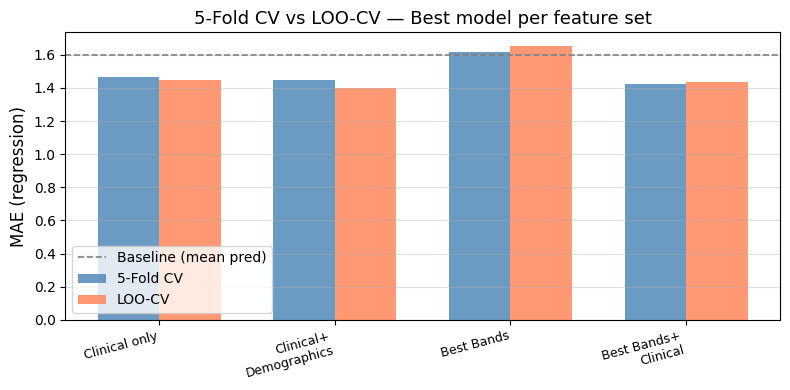

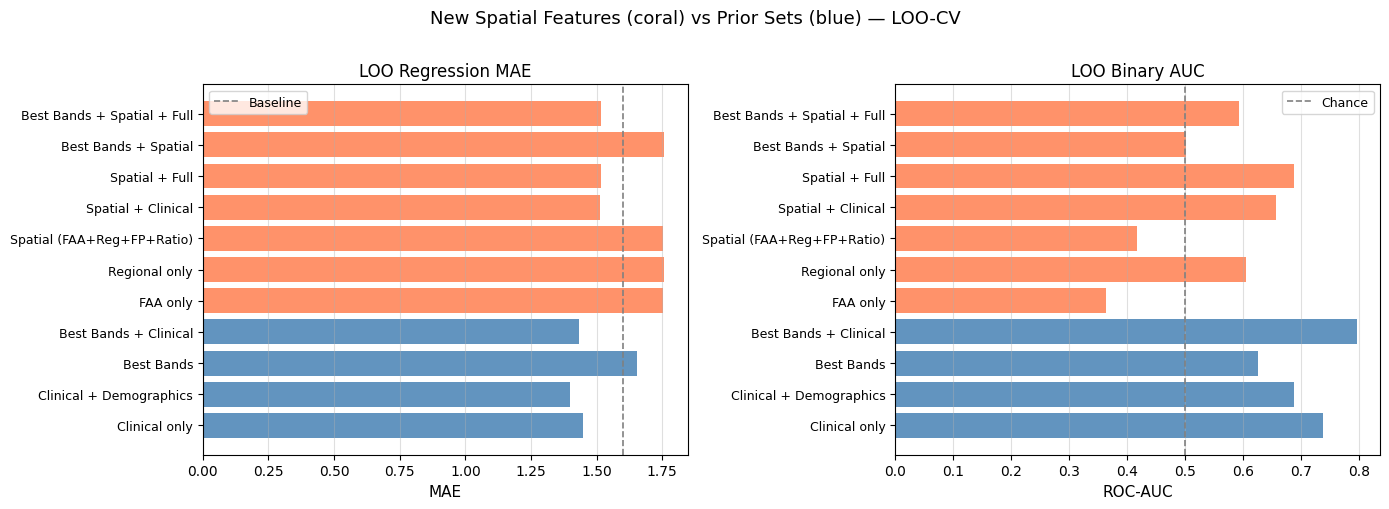

In [29]:
# ── 13d. LOO vs 5-fold comparison plot ──────────────────────────────────────
# Pull 5-fold regression results for sets that appear in both
common_sets = [s for s in loo_reg_results if s in reg_results_all]

if common_sets:
    fivefold_mae  = [reg_results_all[s]['MAE_mean'].min() for s in common_sets]
    loo_mae       = [loo_reg_results[s]['MAE'].iloc[0]    for s in common_sets]
    labels        = [s.replace(' + ', '+\n') for s in common_sets]

    x = np.arange(len(common_sets))
    w = 0.35
    fig, ax = plt.subplots(figsize=(max(8, len(common_sets)*1.4), 4))
    ax.bar(x - w/2, fivefold_mae, w, label='5-Fold CV', color='steelblue', alpha=0.8)
    ax.bar(x + w/2, loo_mae,      w, label='LOO-CV',    color='coral',     alpha=0.8)
    ax.axhline(1.60, ls='--', color='gray', lw=1.2, label='Baseline (mean pred)')
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9, rotation=15, ha='right')
    ax.set_ylabel('MAE (regression)', fontsize=12)
    ax.set_title('5-Fold CV vs LOO-CV — Best model per feature set', fontsize=13)
    ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.4)
    plt.tight_layout(); plt.show()
else:
    print('Run section 4b (5-fold sweep) before plotting the comparison.')

# Spatial feature sets LOO bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regression
ax = axes[0]
names  = list(loo_reg_results.keys())
maes   = [loo_reg_results[n]['MAE'].iloc[0] for n in names]
colors = ['coral' if 'Spatial' in n or 'FAA' in n or 'Regional' in n or 'ratio' in n.lower()
          else 'steelblue' for n in names]
bars = ax.barh(range(len(names)), maes, color=colors, alpha=0.85)
ax.axvline(1.60, ls='--', color='gray', lw=1.2, label='Baseline')
ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=9)
ax.set_xlabel('MAE', fontsize=11); ax.set_title('LOO Regression MAE', fontsize=12)
ax.legend(fontsize=9); ax.grid(axis='x', alpha=0.4)

# Classification
ax = axes[1]
names2 = list(loo_bin_results.keys())
aucs   = [loo_bin_results[n]['AUC'].iloc[0] for n in names2]
colors2 = ['coral' if 'Spatial' in n or 'FAA' in n or 'Regional' in n
           else 'steelblue' for n in names2]
ax.barh(range(len(names2)), aucs, color=colors2, alpha=0.85)
ax.axvline(0.5, ls='--', color='gray', lw=1.2, label='Chance')
ax.set_yticks(range(len(names2))); ax.set_yticklabels(names2, fontsize=9)
ax.set_xlabel('ROC-AUC', fontsize=11); ax.set_title('LOO Binary AUC', fontsize=12)
ax.legend(fontsize=9); ax.grid(axis='x', alpha=0.4)

plt.suptitle('New Spatial Features (coral) vs Prior Sets (blue) — LOO-CV',
             fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


---
## 14. 5_demog-Best Replication
Applies the exact techniques from `5_demog-Best.ipynb` that outperform the base pipeline:
- **Threshold −2.0** instead of median split
- **`RandomizedSearchCV` (n_iter=300)** with `loguniform` distributions over `min_child_weight`, `gamma`, `reg_lambda`, `reg_alpha`
- **`scale_pos_weight`** (XGBoost-native class balancing, `neg/pos` ratio)
- **No `StandardScaler`** before XGBoost (tree models are invariant to scale)
- **`StratifiedGroupKFold`** with `groups=patient_ids` to prevent leakage
- Runs across all feature sets including new spatial ones

In [30]:
# ── 14a. Setup: threshold, labels, groups ───────────────────────────────────
from scipy.stats import loguniform as sp_loguniform, randint as sp_randint, uniform as sp_uniform
from sklearn.model_selection import StratifiedGroupKFold, RandomizedSearchCV

# ── Binary labels at the clinically meaningful -2.0 threshold ────────────────
# Class 0: improvers  (Diff < -2.0),  Class 1: non-improvers (Diff >= -2.0)
THRESHOLD = -2.0
y_demog = (np.array([clinical.loc[p, 'Diff'] for p in common_ids]) >= THRESHOLD).astype(int)

neg, pos = int((y_demog == 0).sum()), int((y_demog == 1).sum())
scale_pos_weight = neg / pos if pos > 0 else 1.0
print(f'Threshold: {THRESHOLD}')
print(f'Class 0 (improvers, Diff<{THRESHOLD}): {neg}')
print(f'Class 1 (non-improvers):               {pos}')
print(f'scale_pos_weight = {scale_pos_weight:.3f}')

# ── Groups = patient IDs (StratifiedGroupKFold prevents patient leakage) ──────
groups_demog = np.array(common_ids)

# ── CV strategy matching 5_demog-Best ─────────────────────────────────────────
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# ── XGBoost with wide randomised search (no StandardScaler) ──────────────────
if not HAS_XGB:
    print('WARNING: xgboost not installed — install with: pip install xgboost')
else:
    from xgboost import XGBClassifier
    xgb_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        # No StandardScaler: XGBoost is scale-invariant
        ('clf', XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            tree_method='hist',
            random_state=42,
            n_jobs=1,
            verbosity=0,
            scale_pos_weight=scale_pos_weight,
        )),
    ])

    xgb_param_dist = {
        'clf__n_estimators':       sp_randint(200, 2000),
        'clf__max_depth':          sp_randint(2, 8),
        'clf__learning_rate':      sp_loguniform(1e-3, 2e-1),
        'clf__subsample':          sp_uniform(0.5, 0.5),      # 0.5–1.0
        'clf__colsample_bytree':   sp_uniform(0.5, 0.5),      # 0.5–1.0
        'clf__min_child_weight':   sp_randint(1, 15),
        'clf__gamma':              sp_loguniform(1e-3, 10.0),
        'clf__reg_lambda':         sp_loguniform(1e-2, 100.0),
        'clf__reg_alpha':          sp_loguniform(1e-3, 10.0),
    }
    print('XGBoost pipeline and search space ready.')
    print(f'Search space: {len(xgb_param_dist)} hyperparameters, n_iter=300')

# Also build a logistic regression equivalent with randomised search
# for comparison on feature sets where XGBoost overfits
lr_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('clf', LogisticRegression(max_iter=5000, class_weight='balanced',
                               random_state=42)),
])
lr_param_dist = {'clf__C': sp_loguniform(1e-4, 1e2),
                 'clf__penalty': ['l1', 'l2'],
                 'clf__solver': ['saga']}

svm_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('clf', SVC(probability=True, class_weight='balanced', random_state=42)),
])
svm_param_dist = {'clf__C': sp_loguniform(1e-2, 1e3),
                  'clf__kernel': ['rbf', 'linear'],
                  'clf__gamma': ['scale', 'auto']}

print('All pipelines ready.')


Threshold: -2.0
Class 0 (improvers, Diff<-2.0): 53
Class 1 (non-improvers):               54
scale_pos_weight = 0.981
XGBoost pipeline and search space ready.
Search space: 9 hyperparameters, n_iter=300
All pipelines ready.


In [31]:
# ── 14b. Randomised search across all feature sets ──────────────────────────
# Combines original + spatial feature sets
ALL_FS = {**FEATURE_SETS, **SPATIAL_FEATURE_SETS}

N_ITER = 300   # match 5_demog-Best; reduce to 50 for a quick scan

demog_results = {}   # {fsname: {model_name: {bal_acc, auc, best_params}}}

MODELS_TO_TRY = {}
if HAS_XGB:
    MODELS_TO_TRY['XGB'] = (xgb_pipe, xgb_param_dist)
MODELS_TO_TRY['LogReg'] = (lr_pipe, lr_param_dist)
MODELS_TO_TRY['SVM']    = (svm_pipe, svm_param_dist)

for fsname, fs_df in ALL_FS.items():
    available = [p for p in common_ids if p in fs_df.index]
    X_raw = fs_df.loc[available].values.astype(float)
    y_fs  = y_demog[[common_ids.index(p) for p in available]]
    grps  = np.array(available)

    col_ok = np.isnan(X_raw).mean(axis=0) < 0.8
    X_raw  = X_raw[:, col_ok]
    if X_raw.shape[1] == 0:
        continue

    print(f'\n{"="*55}')
    print(f'{fsname}  [{X_raw.shape[0]} pts × {X_raw.shape[1]} feats]')

    fs_res = {}
    for mname, (pipe, pdist) in MODELS_TO_TRY.items():
        from sklearn.base import clone
        rs = RandomizedSearchCV(
            estimator=clone(pipe),
            param_distributions=pdist,
            n_iter=N_ITER,
            scoring='balanced_accuracy',
            cv=StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42),
            n_jobs=-1,
            verbose=0,
            refit=True,
            random_state=42,
        )
        # StratifiedGroupKFold requires groups in fit()
        rs.fit(X_raw, y_fs, groups=grps)
        cv_scores = rs.cv_results_['mean_test_score']
        best_bal_acc = rs.best_score_

        # Compute AUC via cross_val_score with best estimator
        from sklearn.model_selection import cross_val_score
        auc_scores = cross_val_score(
            rs.best_estimator_, X_raw, y_fs, groups=grps,
            cv=StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42),
            scoring='roc_auc', n_jobs=-1
        )
        fs_res[mname] = {
            'bal_acc':    round(best_bal_acc, 4),
            'auc_mean':   round(auc_scores.mean(), 4),
            'auc_std':    round(auc_scores.std(),  4),
            'best_params': rs.best_params_,
        }
        print(f'  {mname:8s}: BalAcc={best_bal_acc:.3f}  AUC={auc_scores.mean():.3f}±{auc_scores.std():.3f}')
    demog_results[fsname] = fs_res

print('\nRandomised search sweep complete.')



Clinical only  [107 pts × 5 feats]
  XGB     : BalAcc=0.702  AUC=0.707±0.085
  LogReg  : BalAcc=0.701  AUC=0.741±0.085
  SVM     : BalAcc=0.686  AUC=0.726±0.099

Clinical + Demographics  [107 pts × 15 feats]
  XGB     : BalAcc=0.702  AUC=0.729±0.070
  LogReg  : BalAcc=0.699  AUC=0.747±0.094
  SVM     : BalAcc=0.655  AUC=0.719±0.129

Power (raw)  [107 pts × 56 feats]
  XGB     : BalAcc=0.536  AUC=0.483±0.082
  LogReg  : BalAcc=0.534  AUC=0.521±0.075
  SVM     : BalAcc=0.516  AUC=0.476±0.060

Power (z-scored)  [107 pts × 40 feats]
  XGB     : BalAcc=0.642  AUC=0.659±0.108
  LogReg  : BalAcc=0.672  AUC=0.696±0.074
  SVM     : BalAcc=0.654  AUC=0.690±0.070

Connectivity  [107 pts × 80 feats]
  XGB     : BalAcc=0.610  AUC=0.600±0.098
  LogReg  : BalAcc=0.630  AUC=0.562±0.109
  SVM     : BalAcc=0.648  AUC=0.643±0.089

All EEG  [107 pts × 204 feats]
  XGB     : BalAcc=0.582  AUC=0.515±0.123
  LogReg  : BalAcc=0.658  AUC=0.647±0.109
  SVM     : BalAcc=0.648  AUC=0.672±0.137

Best Bands  [107 

Top 15 combinations (by AUC):
                Feature Set  Model  BalAcc    AUC   AUC±
      Best Bands + Clinical    SVM  0.7236 0.7762 0.1068
      Best Bands + Clinical    XGB  0.6727 0.7479 0.0809
      Best Bands + Clinical LogReg  0.6991 0.7468 0.0943
    Clinical + Demographics LogReg  0.6991 0.7468 0.0943
Best Bands + Spatial + Full LogReg  0.6991 0.7468 0.0943
             Spatial + Full LogReg  0.6991 0.7468 0.0943
         Spatial + Clinical LogReg  0.6991 0.7468 0.0943
             EEG + Clinical LogReg  0.6991 0.7468 0.0943
Best Bands + Spatial + Full    XGB  0.7009 0.7446 0.1066
              Clinical only LogReg  0.7009 0.7407 0.0854
    Clinical + Demographics    XGB  0.7018 0.7290 0.0705
              Clinical only    SVM  0.6864 0.7264 0.0993
    Clinical + Demographics    SVM  0.6555 0.7192 0.1294
              Clinical only    XGB  0.7018 0.7070 0.0853
                 Best Bands    SVM  0.6855 0.7058 0.0154


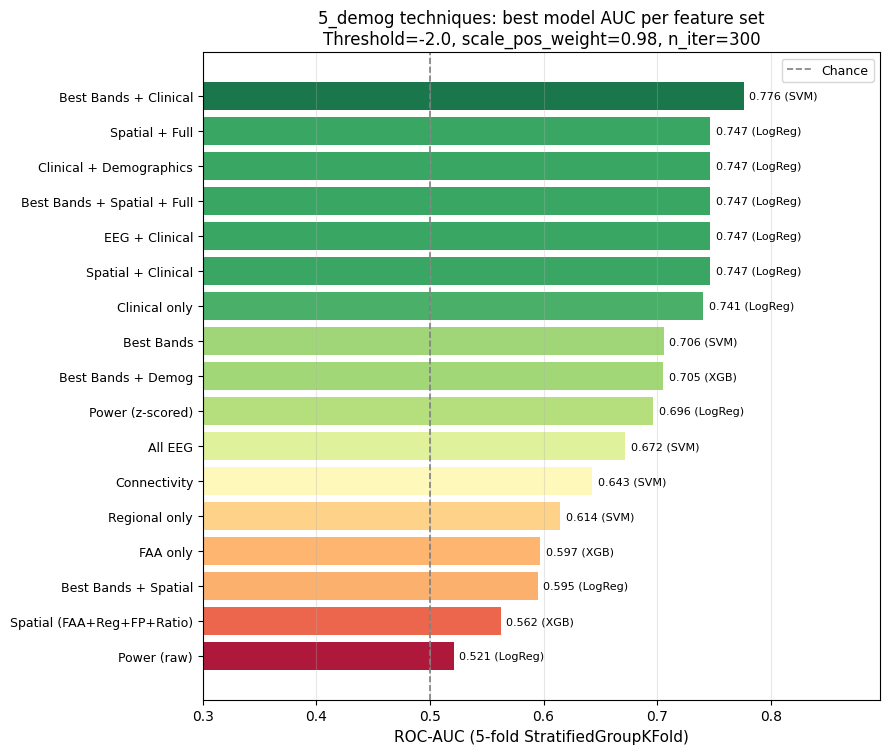

In [32]:
# ── 14c. Results summary — ranked by AUC ────────────────────────────────────
rows = []
for fsname, fs_res in demog_results.items():
    for mname, res in fs_res.items():
        rows.append({
            'Feature Set': fsname,
            'Model':       mname,
            'BalAcc':      res['bal_acc'],
            'AUC':         res['auc_mean'],
            'AUC±':        res['auc_std'],
        })

summary_df = pd.DataFrame(rows).sort_values('AUC', ascending=False)
print('Top 15 combinations (by AUC):')
print(summary_df.head(15).to_string(index=False))

# ── Highlight chart: AUC per feature set (best model per set) ─────────────────
best_per_fs = summary_df.groupby('Feature Set').first().reset_index()
best_per_fs = best_per_fs.sort_values('AUC', ascending=True)

cmap_val  = best_per_fs['AUC'].values
norm      = plt.Normalize(cmap_val.min(), cmap_val.max())
colors    = plt.cm.RdYlGn(norm(cmap_val))

fig, ax = plt.subplots(figsize=(9, max(5, len(best_per_fs)*0.45)))
bars = ax.barh(range(len(best_per_fs)), best_per_fs['AUC'], color=colors, alpha=0.9)
ax.axvline(0.5, ls='--', color='gray', lw=1.2, label='Chance')

for i, (_, row) in enumerate(best_per_fs.iterrows()):
    ax.text(row['AUC'] + 0.005, i, f"{row['AUC']:.3f} ({row['Model']})",
            va='center', fontsize=8)

ax.set_yticks(range(len(best_per_fs)))
ax.set_yticklabels(best_per_fs['Feature Set'], fontsize=9)
ax.set_xlabel('ROC-AUC (5-fold StratifiedGroupKFold)', fontsize=11)
ax.set_title('5_demog techniques: best model AUC per feature set\n'
             f'Threshold={THRESHOLD}, scale_pos_weight={scale_pos_weight:.2f}, n_iter=300',
             fontsize=12)
ax.legend(fontsize=9)
ax.set_xlim(0.3, min(1.05, best_per_fs['AUC'].max() + 0.12))
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


Best combination: Best Bands + Clinical  |  SVM
AUC = 0.7762  BalAcc = 0.7236
Best hyperparameters:
  clf__C: 1.3216304807924908
  clf__gamma: auto
  clf__kernel: rbf


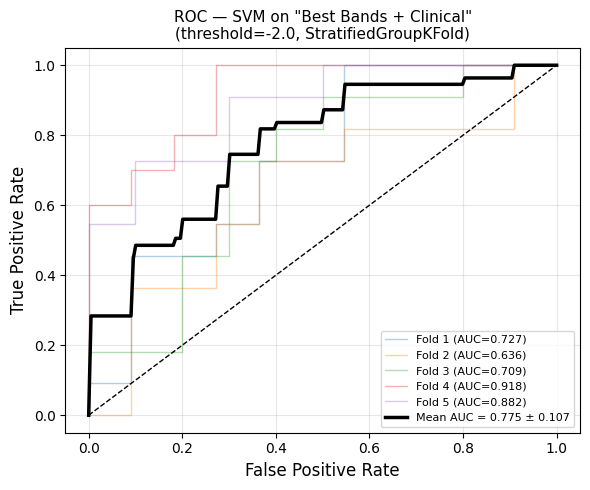

In [34]:
# ── 14d. Best combination: ROC curve + hyperparameters ──────────────────────
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_curve
from sklearn.base import clone

# Identify overall best (feature set, model)
best_row   = summary_df.iloc[0]
best_fs    = best_row['Feature Set']
best_model = best_row['Model']
best_params = demog_results[best_fs][best_model]['best_params']

print(f'Best combination: {best_fs}  |  {best_model}')
print(f'AUC = {best_row["AUC"]:.4f}  BalAcc = {best_row["BalAcc"]:.4f}')
print(f'Best hyperparameters:')
for k, v in best_params.items():
    print(f'  {k}: {v}')

# Re-fit best pipeline with its params to get per-fold ROC curves
fs_df    = ALL_FS[best_fs]
available = [p for p in common_ids if p in fs_df.index]
X_best   = fs_df.loc[available].values.astype(float)
y_best   = y_demog[[common_ids.index(p) for p in available]]
grps_best = np.array(available)
col_ok   = np.isnan(X_best).mean(axis=0) < 0.8
X_best   = X_best[:, col_ok]

pipe_best, pdist_best = MODELS_TO_TRY[best_model]
fitted_pipe = clone(pipe_best).set_params(**best_params)

cv_plot = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
fig, ax = plt.subplots(figsize=(6, 5))
fold_aucs, tprs_list = [], []
mean_fpr = np.linspace(0, 1, 200)

for fold_i, (tr, te) in enumerate(cv_plot.split(X_best, y_best, groups=grps_best), 1):
    m = clone(fitted_pipe)
    m.fit(X_best[tr], y_best[tr])
    proba = m.predict_proba(X_best[te])[:, 1]
    fpr, tpr, _ = roc_curve(y_best[te], proba)
    auc_i = float(np.trapz(tpr, fpr))
    fold_aucs.append(auc_i)
    tprs_list.append(np.interp(mean_fpr, fpr, tpr))
    tprs_list[-1][0] = 0.0
    ax.plot(fpr, tpr, alpha=0.35, lw=1, label=f'Fold {fold_i} (AUC={auc_i:.3f})')

mean_tpr = np.mean(tprs_list, axis=0); mean_tpr[-1] = 1.0
ax.plot(mean_fpr, mean_tpr, 'k-', lw=2.5,
        label=f'Mean AUC = {np.mean(fold_aucs):.3f} ± {np.std(fold_aucs):.3f}')
ax.plot([0,1],[0,1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f'ROC — {best_model} on "{best_fs}"\n(threshold={THRESHOLD}, StratifiedGroupKFold)', fontsize=11)
ax.legend(fontsize=8, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
